# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 46 |  |
| :-------------|:-------------|
| Tim Omloo | 6567010 |
| Marjoksi Elyas| 6243355 |
| Steven Wijnands| 6580912|

In [2]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Tim', 'Marjoksi','Steven']

## Opdracht 1: Planning.

| Planning Groep: 46     |Tijdstip / Tijdspanne  |
|---|---|
| Voorbereiding | 11:00 - 11:15 |
| Kalibreren sensor | 11:15 - 11:45|
| Meetopsteling testen | 11:45 - 12:00 |
| Iteratie 1 begin | 12:00 - 12:30 |
| Pauze | 12:30 - 13:30 |
| Iteratie 1 | 13:30 - 15:30 |
| Iteratie 2 | 15:30 - 16:30 |

## Opdracht 2: Import libs.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [nummer]
<img src="tudelftLogo.png" width="400">

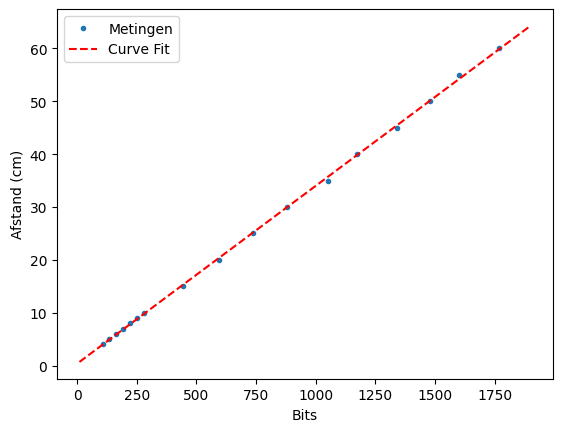

[0.03363692 0.34863315]


In [4]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

bits = np.array([110,135,165,193,223,250,280,444,596,737,882,1050,1174,1340,1480,1600,1770]) #bits
afstanden = np.array([4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,55,60]) #cm

def fit(x,a,b):
    return a*x + b

ppov,pcov = curve_fit(fit,bits,afstanden)
x_test = np.linspace(10,1900,1000)

plt.figure()
plt.plot(bits,afstanden,'.',label='Metingen')
plt.plot(x_test,fit(x_test,*ppov),'r--',label='Curve Fit')
plt.xlabel('Bits')
plt.ylabel('Afstand (cm)')
plt.legend()
plt.show()

print(ppov)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  48.1
1   0  30   0  20  48.8
2  40   0  30   0  46.8
3  30   0  20   0  46.1


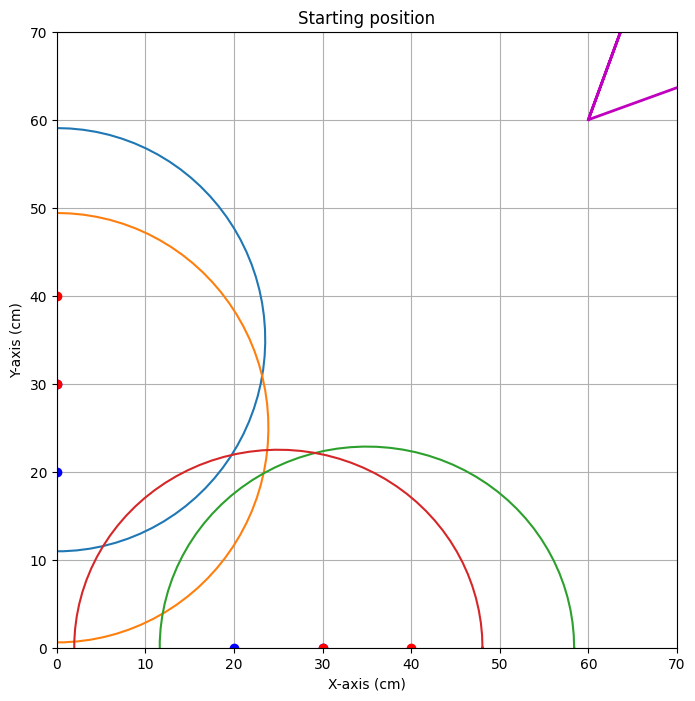


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=94.505


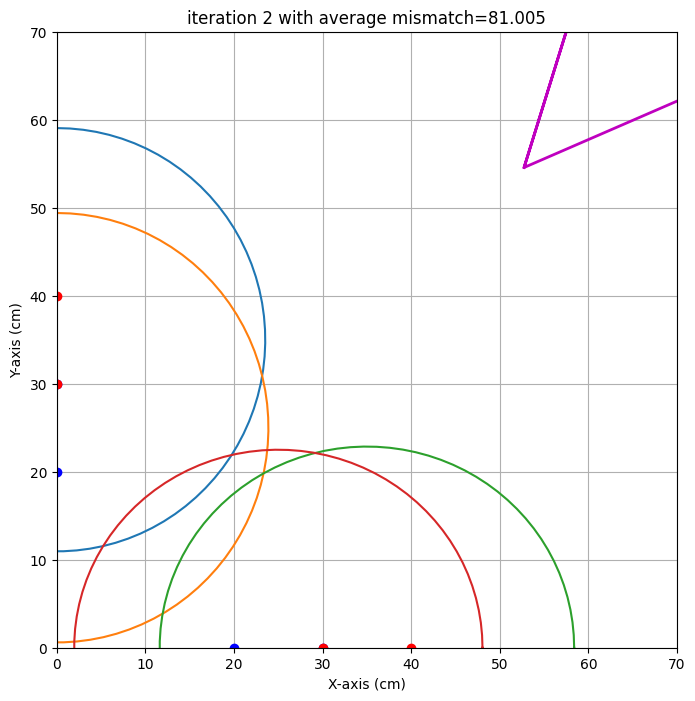

end iteration 2 with average mismatch=81.005


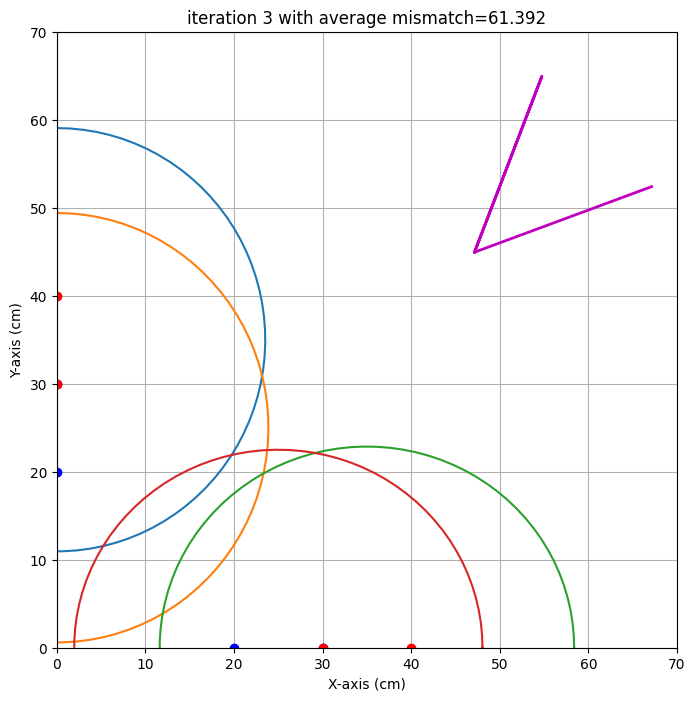

end iteration 3 with average mismatch=61.392


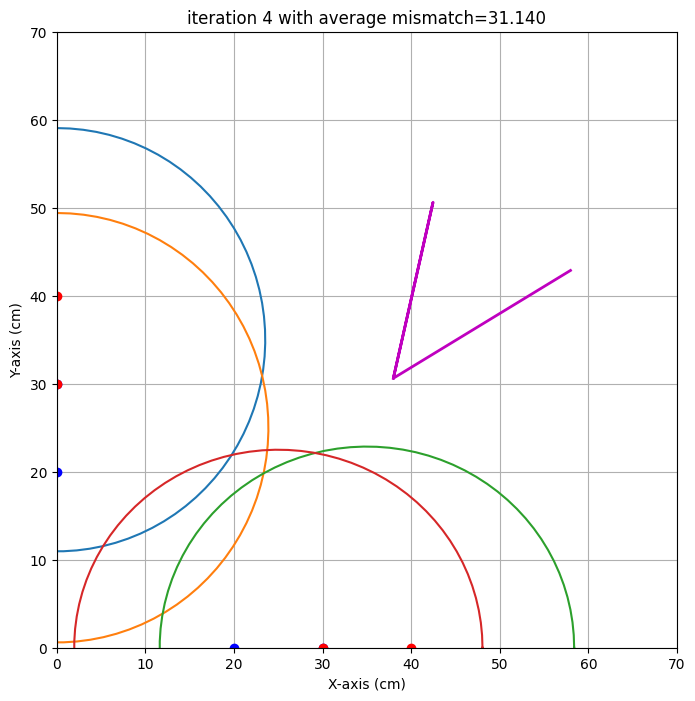

end iteration 4 with average mismatch=31.140


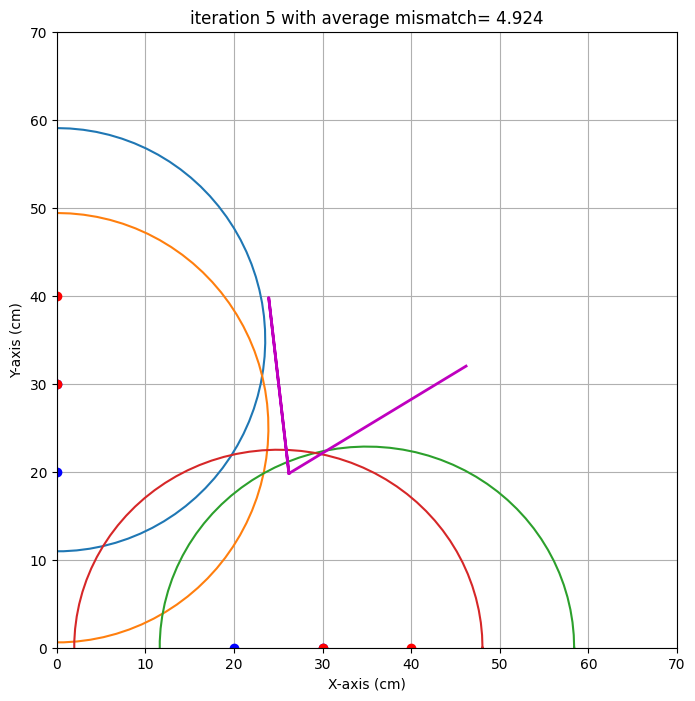

end iteration 5 with average mismatch= 4.924


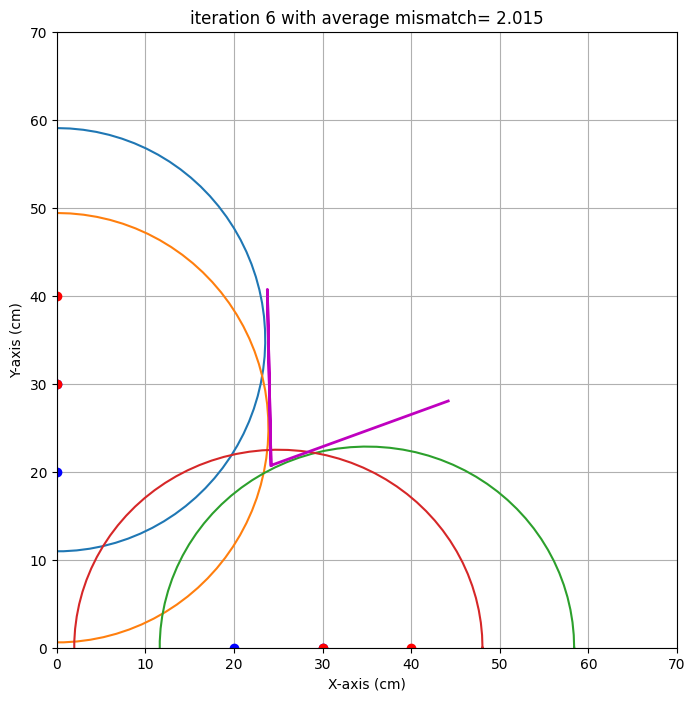

end iteration 6 with average mismatch= 2.015


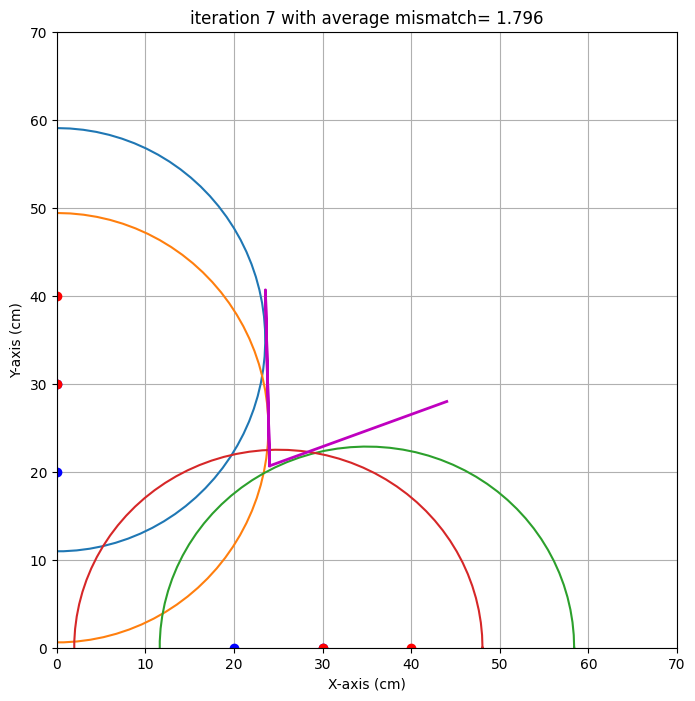

end iteration 7 with average mismatch= 1.796
end iteration 8 with average mismatch= 1.694


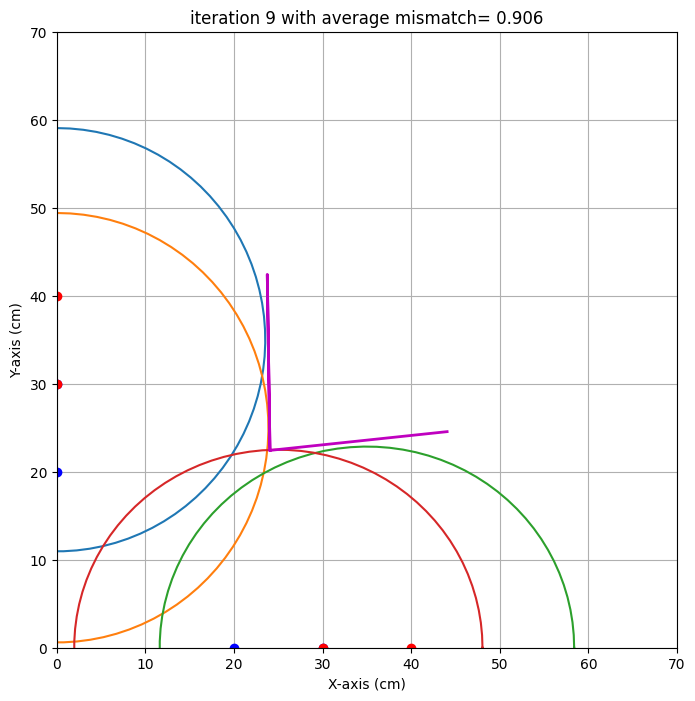

end iteration 9 with average mismatch= 0.906


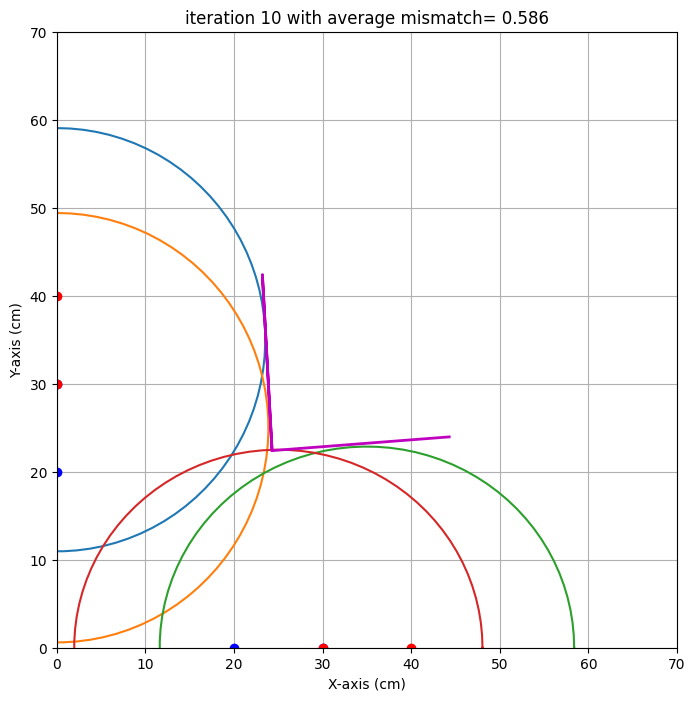

end iteration 10 with average mismatch= 0.586
end iteration 11 with average mismatch= 0.579
end iteration 12 with average mismatch= 0.576
end iteration 13 with average mismatch= 0.576
end iteration 14 with average mismatch= 0.576


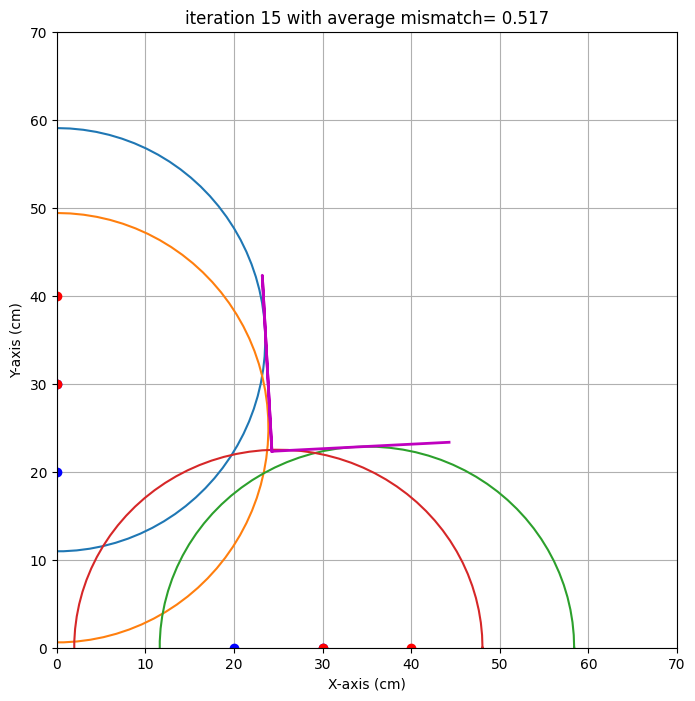

end iteration 15 with average mismatch= 0.517
end iteration 16 with average mismatch= 0.472
end iteration 17 with average mismatch= 0.470
end iteration 18 with average mismatch= 0.470
end iteration 19 with average mismatch= 0.470


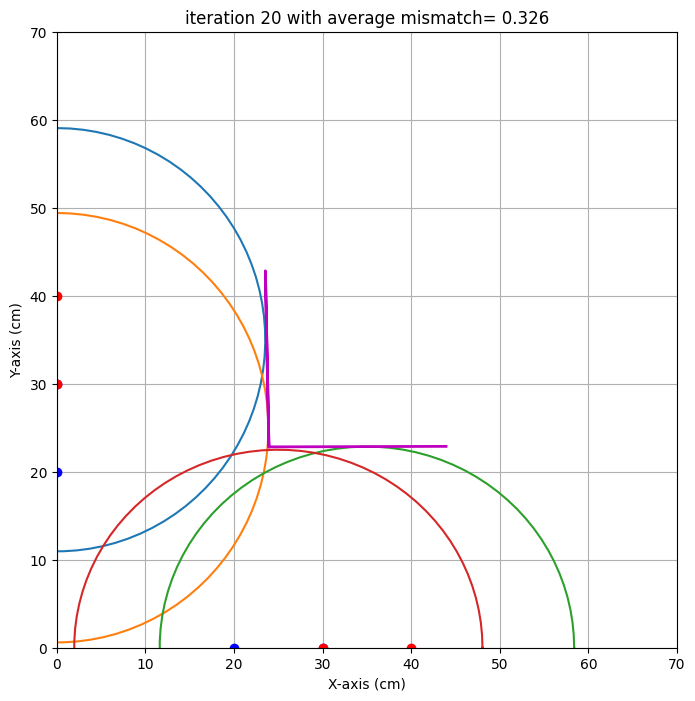

end iteration 20 with average mismatch= 0.326
end iteration 21 with average mismatch= 0.321


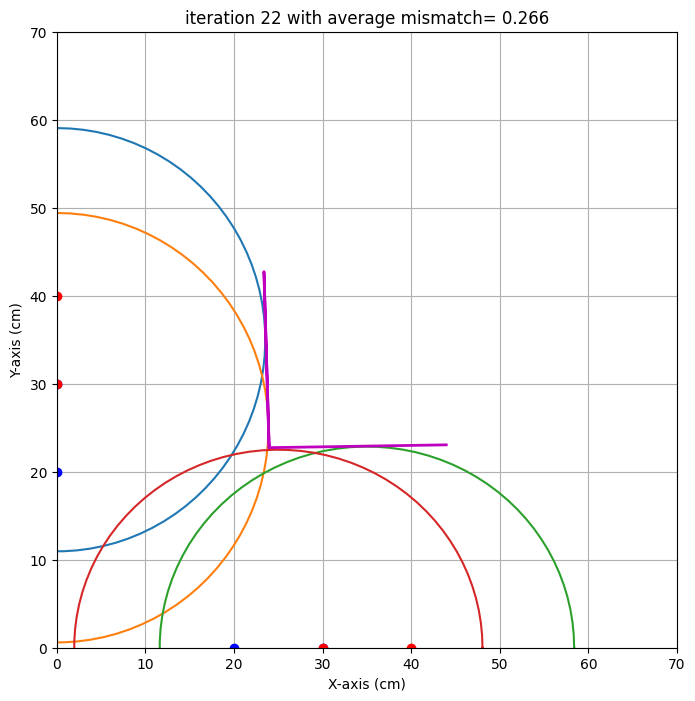

end iteration 22 with average mismatch= 0.266
end iteration 23 with average mismatch= 0.249
end iteration 24 with average mismatch= 0.248
end iteration 25 with average mismatch= 0.248
end iteration 26 with average mismatch= 0.248
end iteration 27 with average mismatch= 0.248
end iteration 28 with average mismatch= 0.248
end iteration 29 with average mismatch= 0.248
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.248
###############################################################################
end of iteration  30
Best alpha=   0.91 with uncertainty=   1.52
Best beta =  -1.68 with uncertainty=   0.21
Best x0   =  23.95 with uncertainty=   0.03
Best y0   =  22.72 with uncertainty=   0.33
###############################################################################


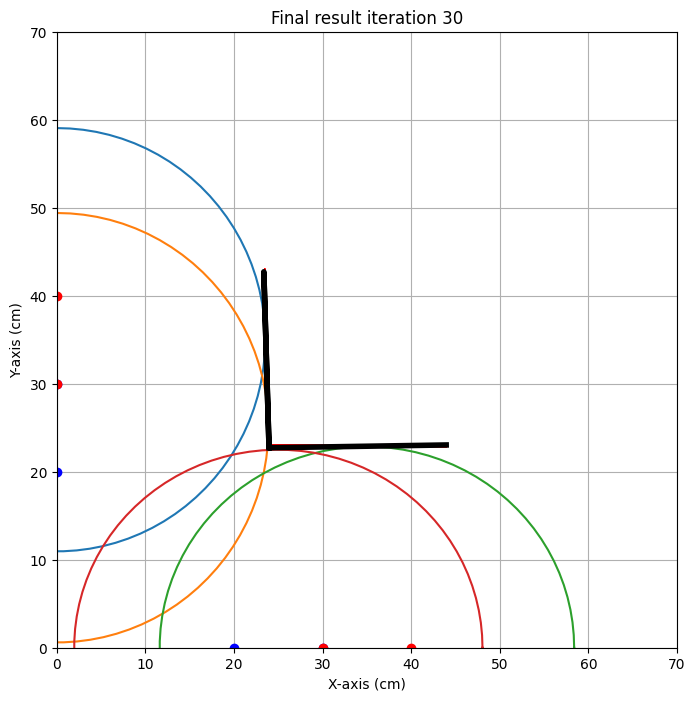

In [5]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

#origin is 2.5 centimeter naar achter geplaats, waardoor het karton niet op 20 maar 22.5 cm staat.

dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,48.1],
    [0,30,0,20,48.8],
#   [0,10,0,20,170.0],
    [40,0,30,0,46.8],
    [30,0,20,0,46.1],
#    [10,0,20,0,165.0],
#   [10,0,0,10,180.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [6]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 23.9 cm met een standaardafwijking van 0.0 cm 
y0: 22.7 cm met een standaardafwijking van 0.3 cm 
alpha: 0.9 graden met een standaardafwijking van 1.5 graad 
beta: -1.7 graden met een standaardafwijking van 0.2 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Tim]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Tim.png" width="400">

#### algoritme [Marjoksi]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Marjoksi.png" width="400">

#### algoritme [Steven]
Voeg een foto in van het algoritme van het derde groepslid
<img src="Steven.png" width="400">

In [7]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [8]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': 23.5,
           'alpha' : 14,
           'beta' : 10
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Steven' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[0,70,0,60,170] ongeldig
   [0,30,0,20,64.8],
   [0,40,0,30,62.3],
   [0,20,0,10,62.8],
   #[70,0,60,0,130] ongeldig 
   [30,0,20,0,53.0],
   [40,0,30,0,48.1]
    ]),
  'Marjoksi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,10,0,170] ongeldig
    [30,0,20,0,54.1],
    [40,0,30,0,53.3],
    [50,0,40,0,44.1],
    #[60,0,50,0,180] ongeldig
    [0,30,0,20,63.1],
    [0,40,0,30,59.7]
    #[0,40,0,50,170] ongeldig

    ]),
    'Tim' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    ])
      }

## Opdracht 7: Evaluatie.

Tim
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


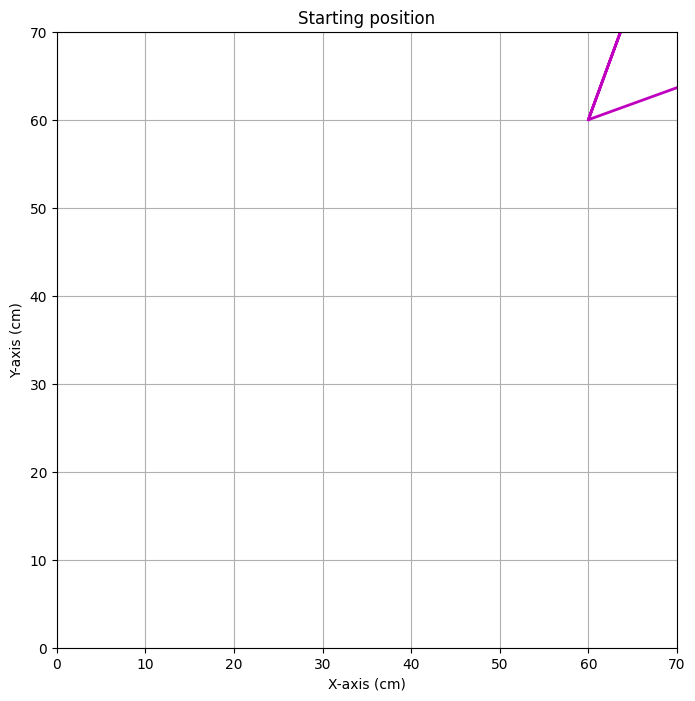


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 21 with average mismatch=   nan
end iteration 22 with average mismatch=   nan
end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatch=   nan
end iteration 29 with average mismatch=   nan
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch=   nan
###############################################################################
end of iteration  30
Best alpha=    nan with uncertainty=   0.00
Best beta =    nan with uncertainty=   0.00
Best x0   =    nan with uncertainty=   0.00
Best y0   =    nan with uncertainty=   0.00
###############################################################################
no uncertainty found, pl

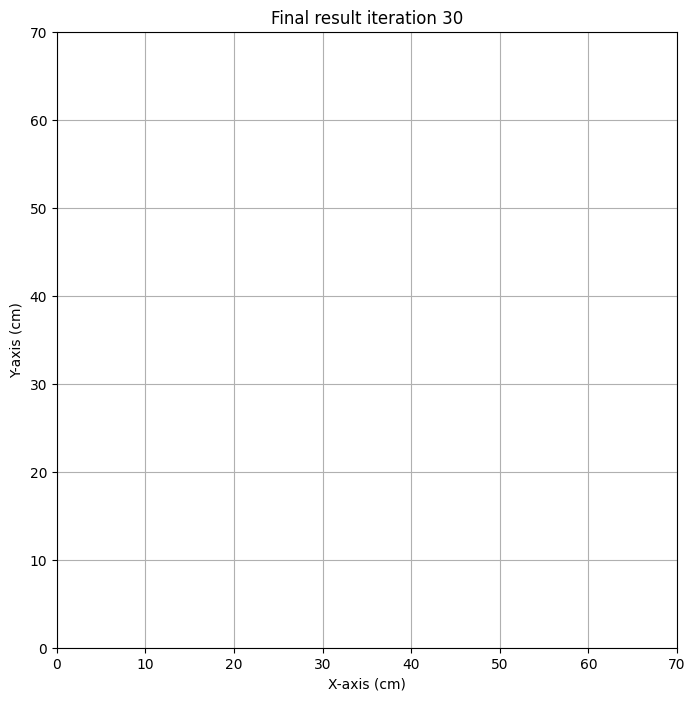

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}
Marjoksi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  20   0  54.1
1  40   0  30   0  53.3
2  50   0  40   0  44.1
3   0  30   0  20  63.1
4   0  40   0  30  59.7


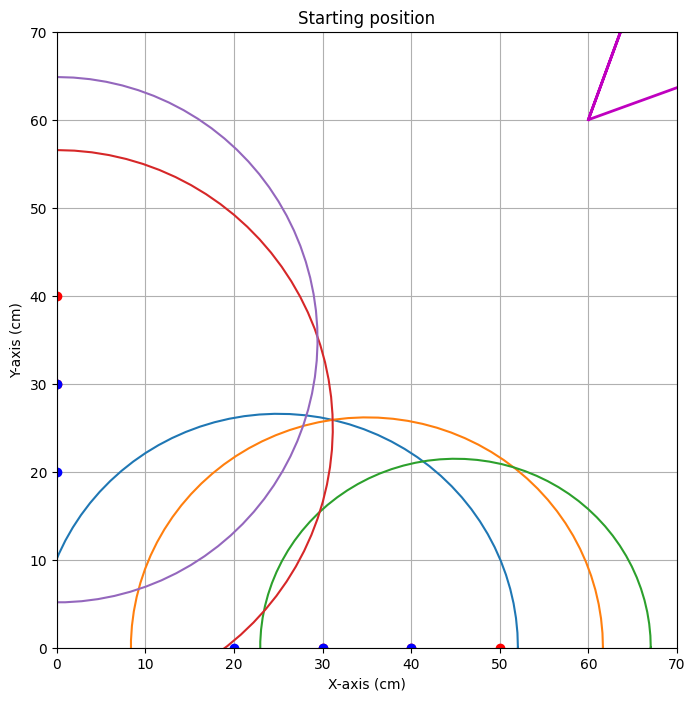


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.332


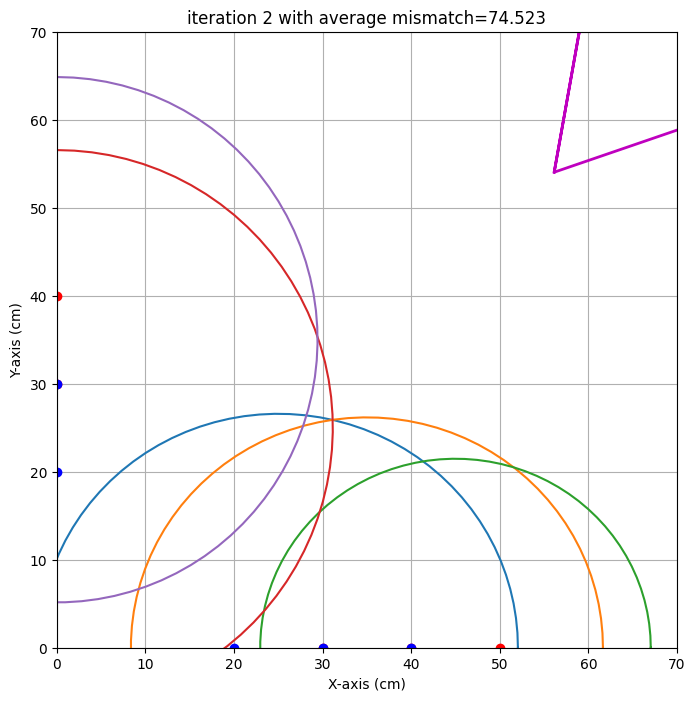

end iteration 2 with average mismatch=74.523


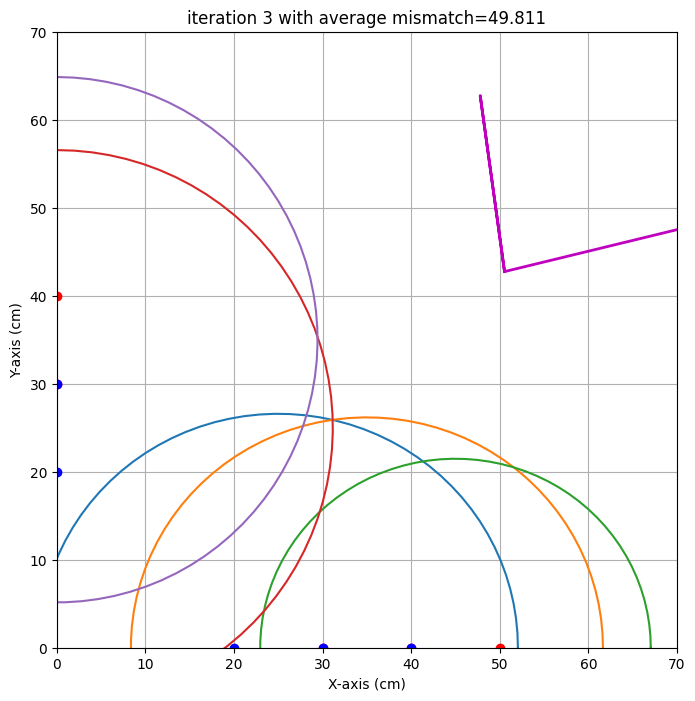

end iteration 3 with average mismatch=49.811


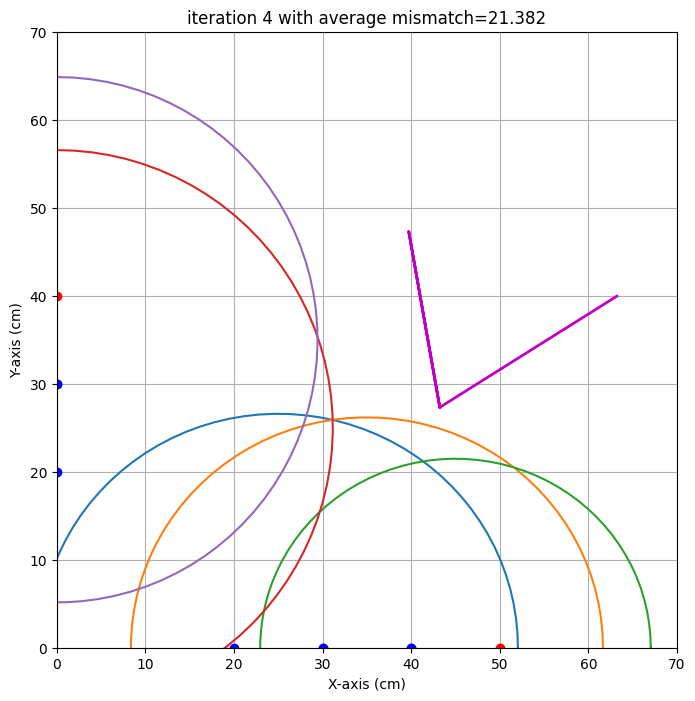

end iteration 4 with average mismatch=21.382


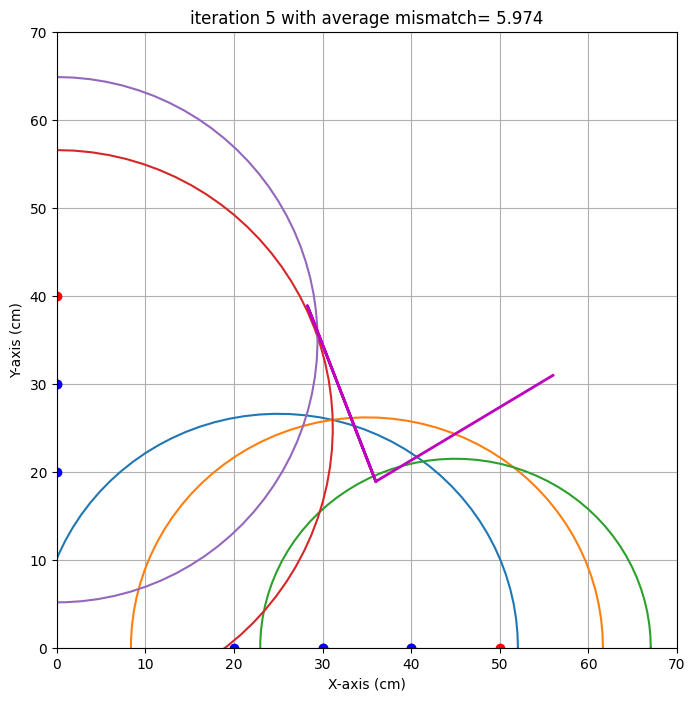

end iteration 5 with average mismatch= 5.974
end iteration 6 with average mismatch= 5.553
end iteration 7 with average mismatch= 5.445
end iteration 8 with average mismatch= 5.441


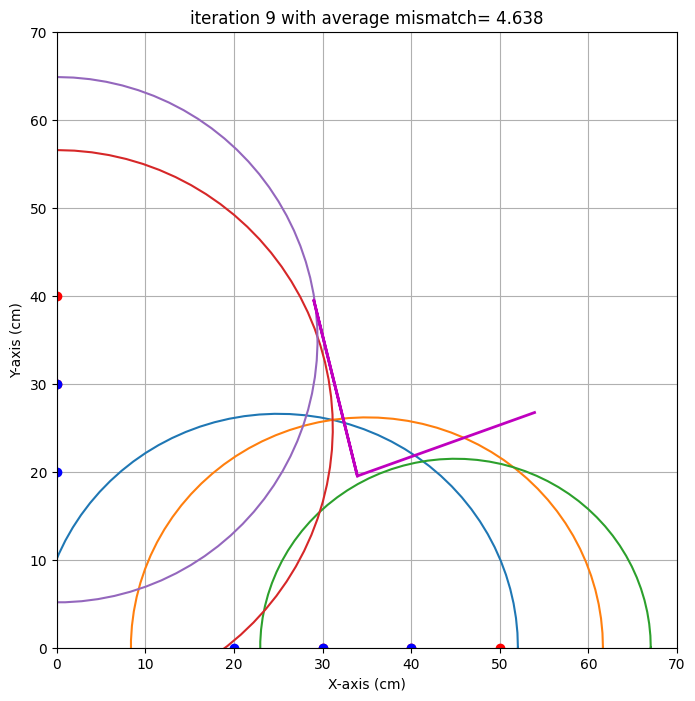

end iteration 9 with average mismatch= 4.638
end iteration 10 with average mismatch= 4.419
end iteration 11 with average mismatch= 4.347
end iteration 12 with average mismatch= 4.173
end iteration 13 with average mismatch= 4.162
end iteration 14 with average mismatch= 4.141
end iteration 15 with average mismatch= 4.140
end iteration 16 with average mismatch= 4.140
end iteration 17 with average mismatch= 4.140
end iteration 18 with average mismatch= 4.140
end iteration 19 with average mismatch= 4.140
end iteration 20 with average mismatch= 4.140
end iteration 21 with average mismatch= 4.140
end iteration 22 with average mismatch= 4.140
end iteration 23 with average mismatch= 4.140
end iteration 24 with average mismatch= 4.140
end iteration 25 with average mismatch= 4.140
end iteration 26 with average mismatch= 4.140
end iteration 27 with average mismatch= 4.140
end iteration 28 with average mismatch= 4.140
end iteration 29 with average mismatch= 4.140
Last iteration, also determine unce

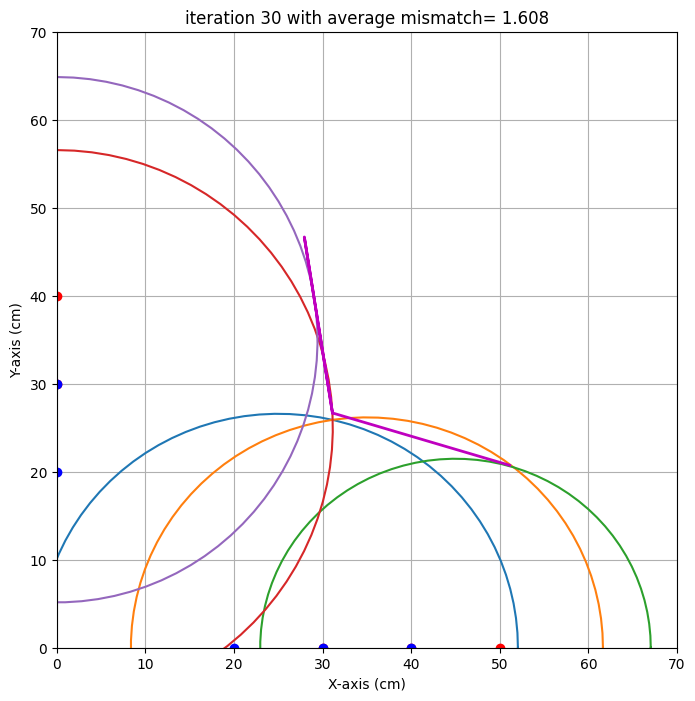

end iteration 30 with average mismatch= 1.608
###############################################################################
end of iteration  30
Best alpha= -16.56 with uncertainty=   2.68
Best beta =  -9.04 with uncertainty=   6.40
Best x0   =  31.11 with uncertainty=   1.16
Best y0   =  26.68 with uncertainty=   1.02
###############################################################################


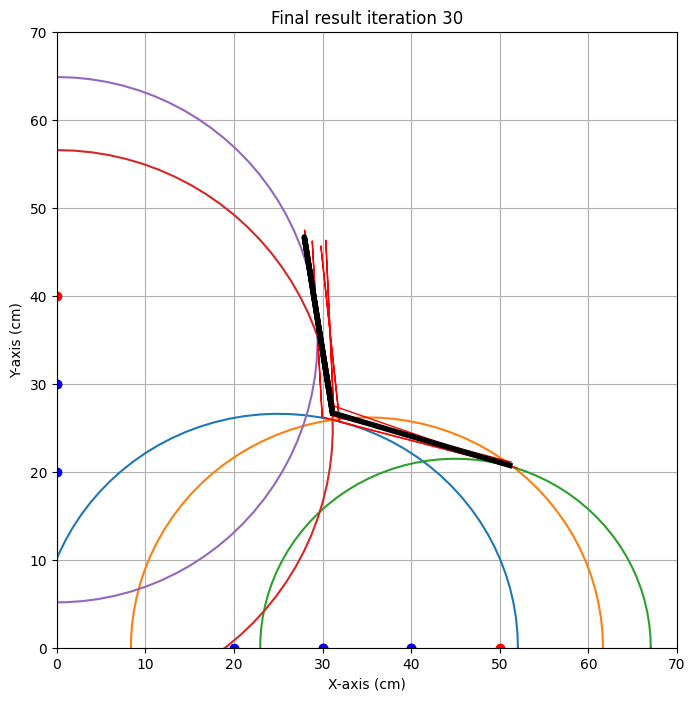

{'alpha': np.float64(-16.55666545410671), 'alpha_eps': np.float64(2.6777795371447617), 'beta': np.float64(-9.038775355101064), 'beta_eps': np.float64(6.403582346472966), 'x0': np.float64(31.114068258700346), 'x0_eps': np.float64(1.1613886814960068), 'y0': np.float64(26.676584108935263), 'y0_eps': np.float64(1.0225972491995776)}
Steven
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  20  64.8
1   0  40   0  30  62.3
2   0  20   0  10  62.8
3  30   0  20   0  53.0
4  40   0  30   0  48.1


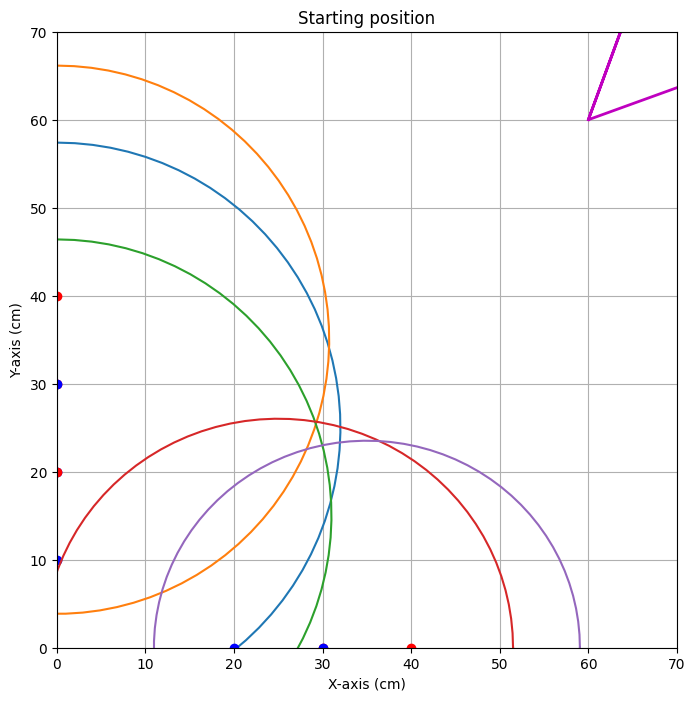


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=86.766


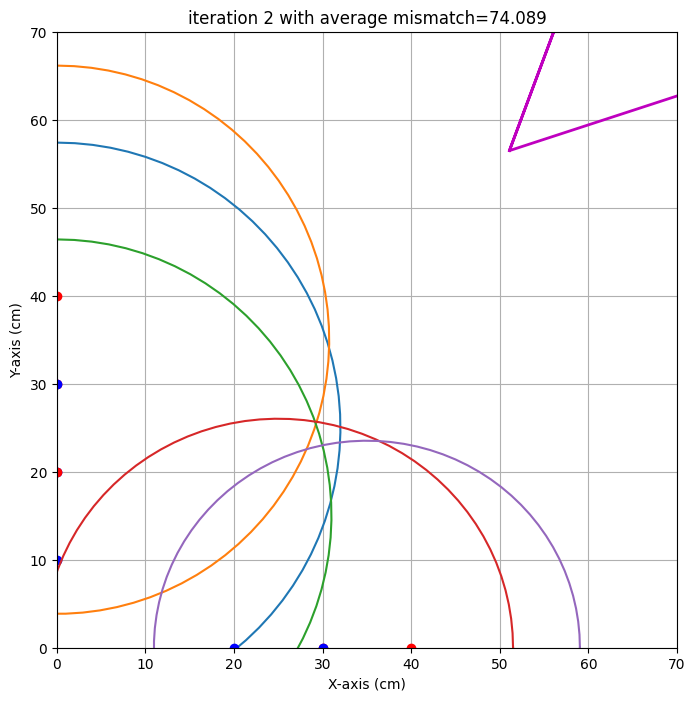

end iteration 2 with average mismatch=74.089


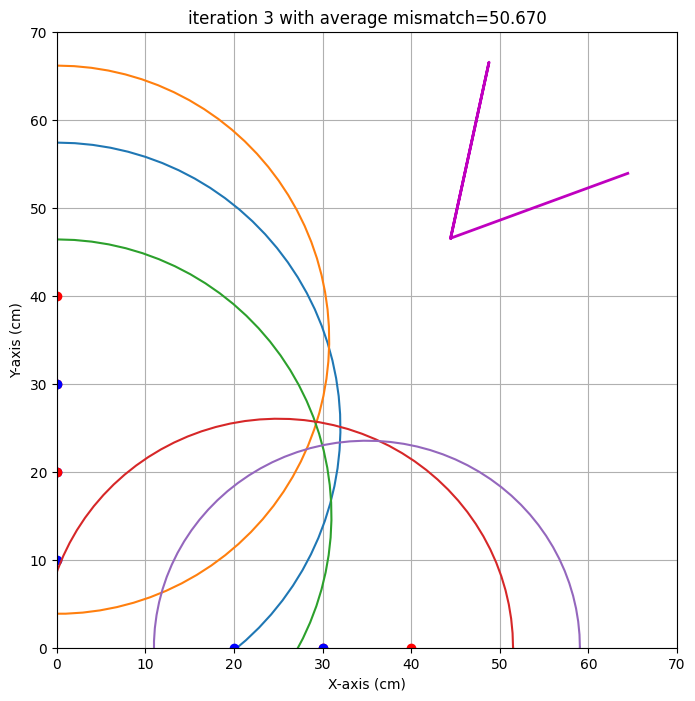

end iteration 3 with average mismatch=50.670


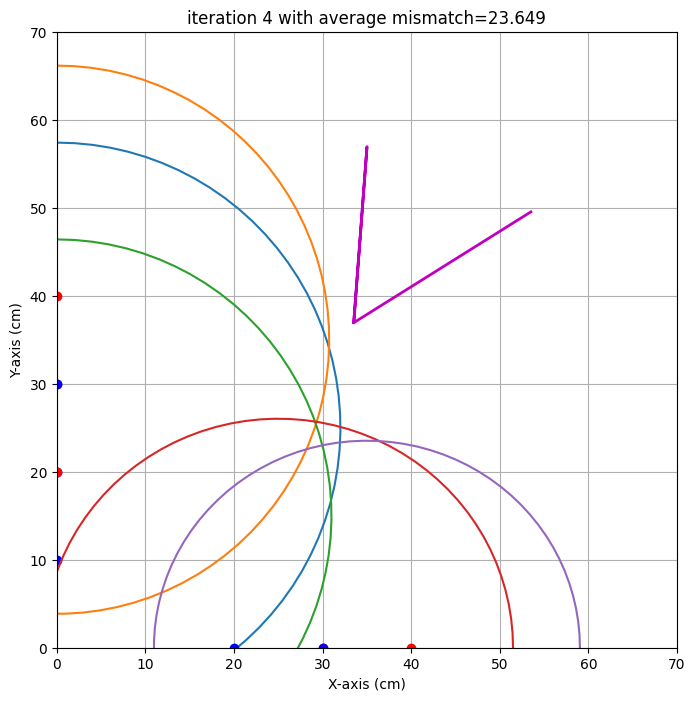

end iteration 4 with average mismatch=23.649


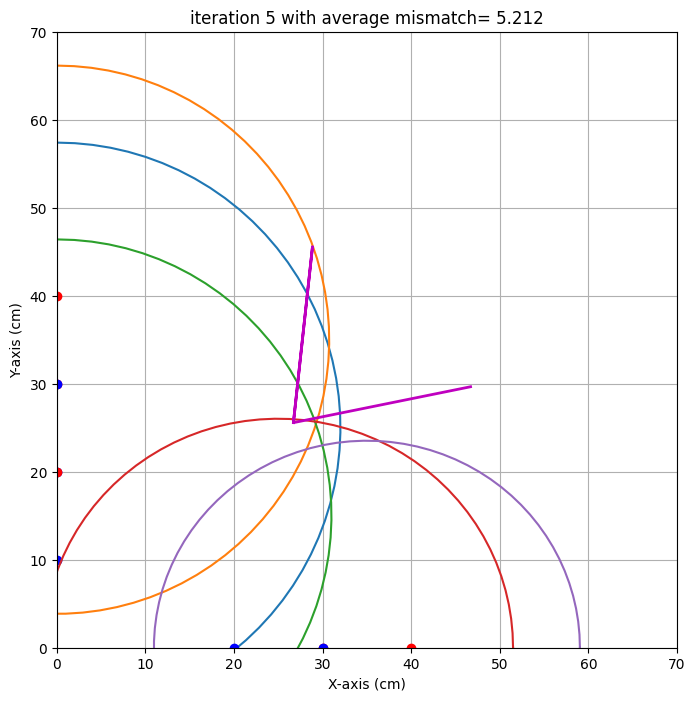

end iteration 5 with average mismatch= 5.212


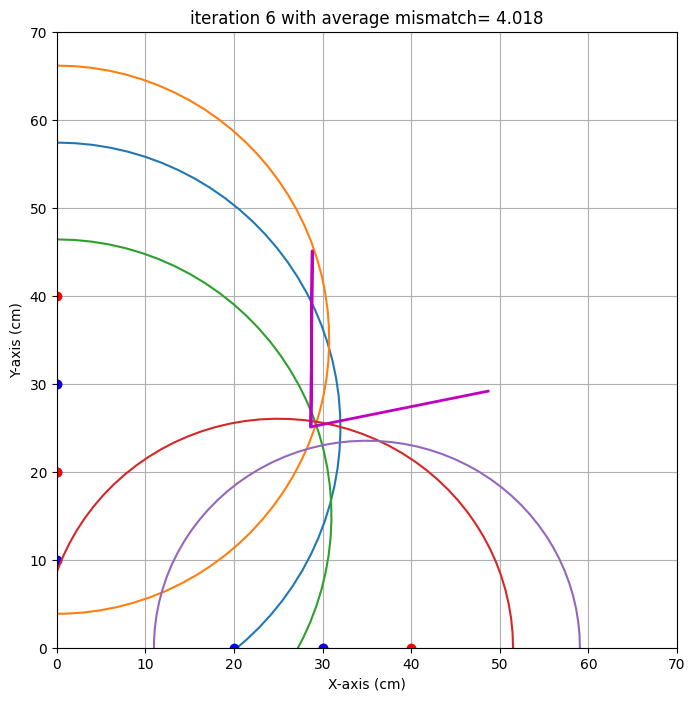

end iteration 6 with average mismatch= 4.018
end iteration 7 with average mismatch= 3.624
end iteration 8 with average mismatch= 3.387
end iteration 9 with average mismatch= 3.142
end iteration 10 with average mismatch= 2.935
end iteration 11 with average mismatch= 2.935
end iteration 12 with average mismatch= 2.935
end iteration 13 with average mismatch= 2.935
end iteration 14 with average mismatch= 2.935
end iteration 15 with average mismatch= 2.907
end iteration 16 with average mismatch= 2.773
end iteration 17 with average mismatch= 2.773
end iteration 18 with average mismatch= 2.773
end iteration 19 with average mismatch= 2.773
end iteration 20 with average mismatch= 2.712
end iteration 21 with average mismatch= 2.670


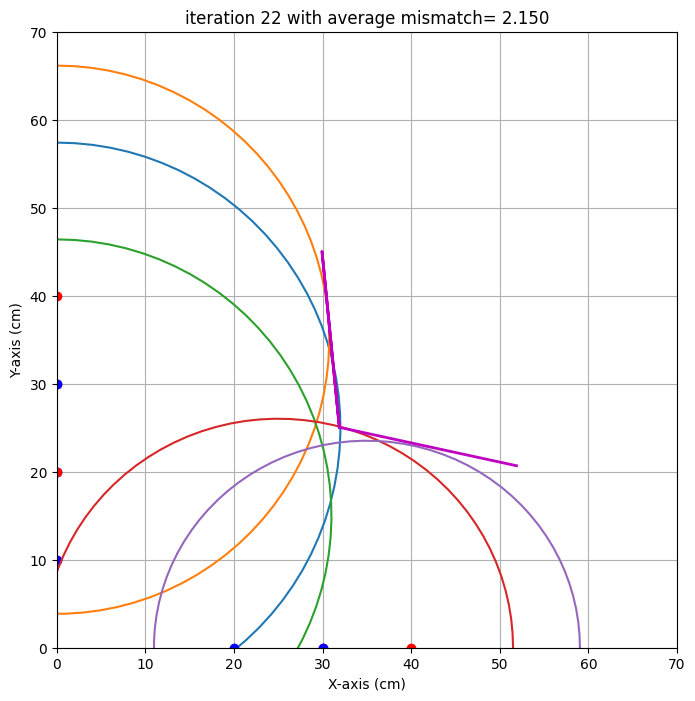

end iteration 22 with average mismatch= 2.150
end iteration 23 with average mismatch= 1.947
end iteration 24 with average mismatch= 1.936
end iteration 25 with average mismatch= 1.928
end iteration 26 with average mismatch= 1.927
end iteration 27 with average mismatch= 1.927
end iteration 28 with average mismatch= 1.927
end iteration 29 with average mismatch= 1.927
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.927
###############################################################################
end of iteration  30
Best alpha= -13.81 with uncertainty=   2.26
Best beta =  -6.70 with uncertainty=   8.08
Best x0   =  32.14 with uncertainty=   2.76
Best y0   =  24.96 with uncertainty=   1.14
###############################################################################


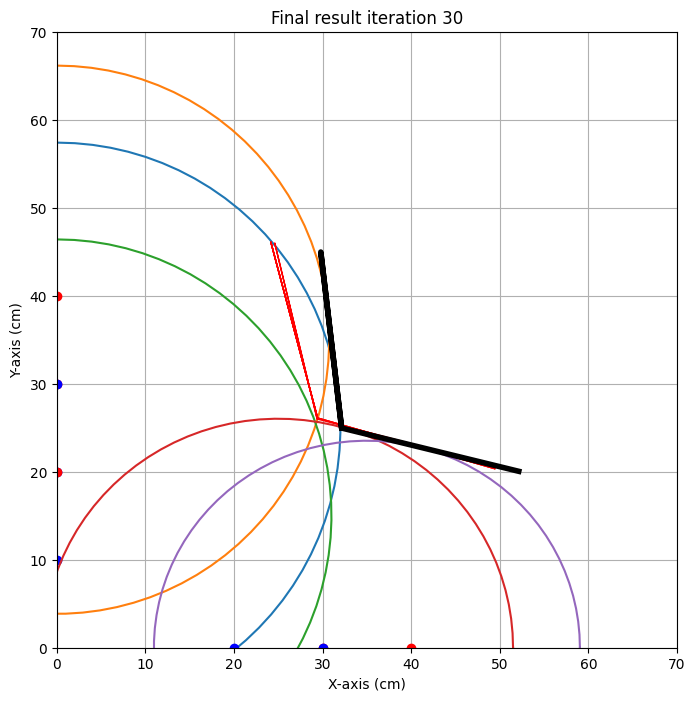

{'alpha': np.float64(-13.811177841295395), 'alpha_eps': np.float64(2.2554801202489205), 'beta': np.float64(-6.704398369047561), 'beta_eps': np.float64(8.084571566718399), 'x0': np.float64(32.14410227530986), 'x0_eps': np.float64(2.763627273485543), 'y0': np.float64(24.96418743059056), 'y0_eps': np.float64(1.1429255747858633)}


In [9]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [10]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Tim 
x0 target is : 33.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 23.5. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 14.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : 10.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 

Marjoksi 
x0 target is : 33.0. Gevonden waarde: 31.1 cm met een standaardafwijking van 1.2 cm 
y0 target is : 23.5. Gevonden waarde: 26.7 cm met een standaardafwijking van 1.0 cm 
alpha target is : 14.0. Gevonden waarde: -16.6 graden met een standaardafwijking van 2.7 graad 
beta target is : 10.0. Gevonden waarde: -9.0 graden met een standaardafwijking van 6.4 graad 

Steven 
x0 target is : 33.0. Gevonden waarde: 32.1 cm met een standaardafwijking van 2.8 cm 
y0 target is : 23.5. Gevonden waarde: 25.0 cm met een standaardafwijking van 1.1 cm 
alpha target is : 14.0. Gevonden waarde: -13.8 graden met een standaardafwijking van 2.3 g

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Eindalgoritme.png)


In [11]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  20   0   72.9
1  40   0  30   0   67.5
2  35   0  25   0   68.8
3   0  70   0  60   93.8
4   0  65   0  55   88.6
5   0  60   0  50  110.0
6   0  55   0  45  100.0
7   0  50   0  40  110.0


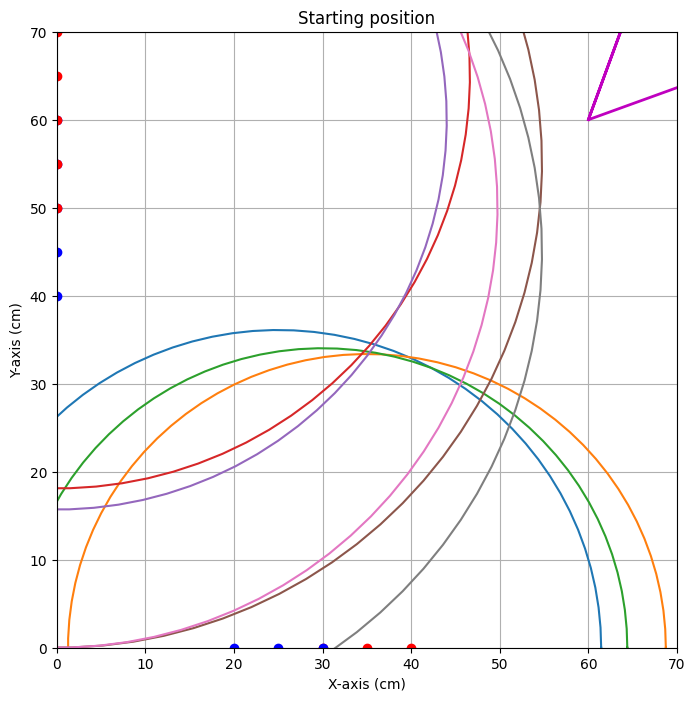


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.218


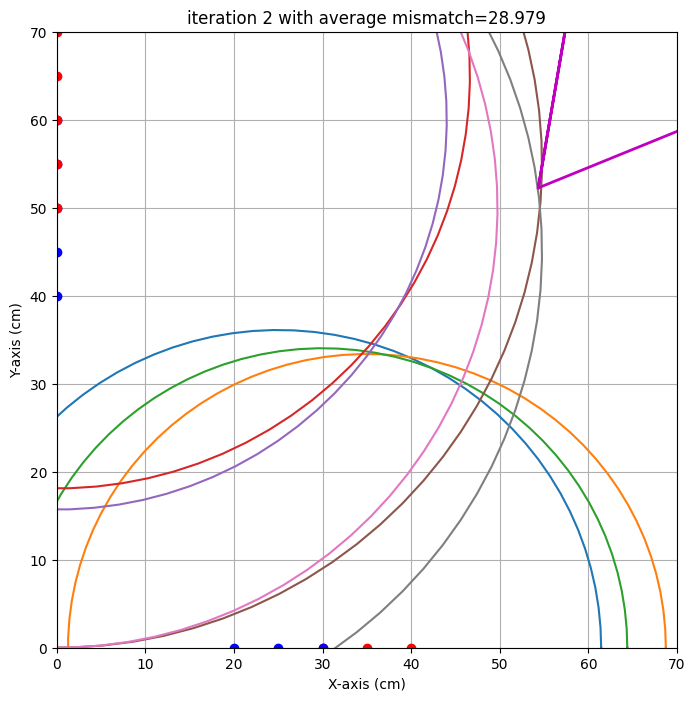

end iteration 2 with average mismatch=28.979


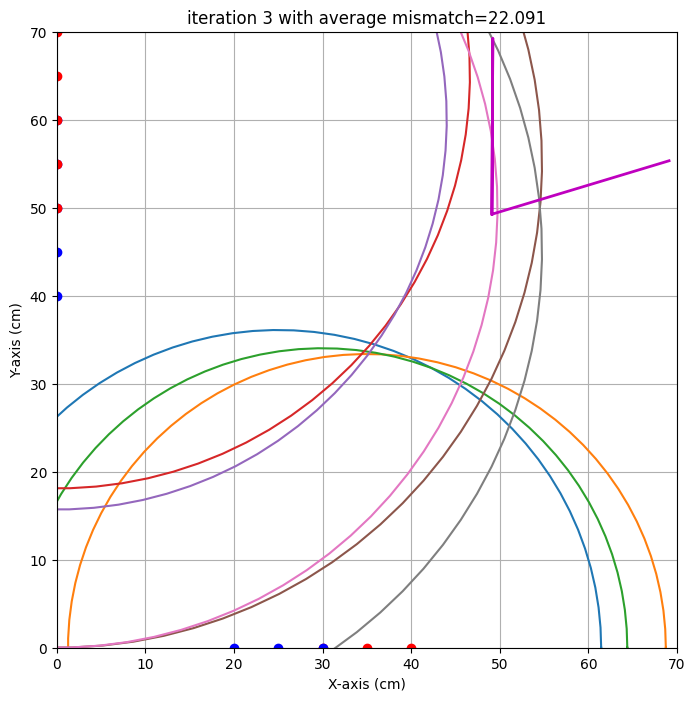

end iteration 3 with average mismatch=22.091


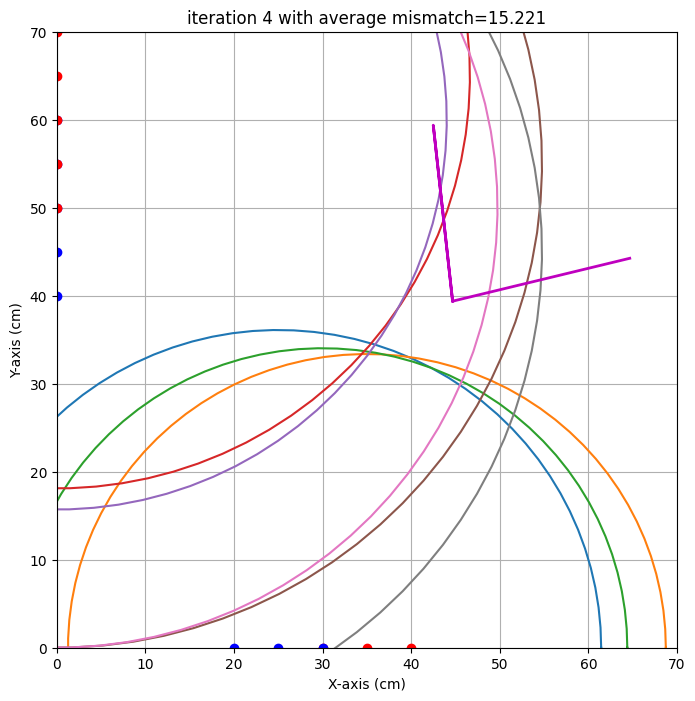

end iteration 4 with average mismatch=15.221


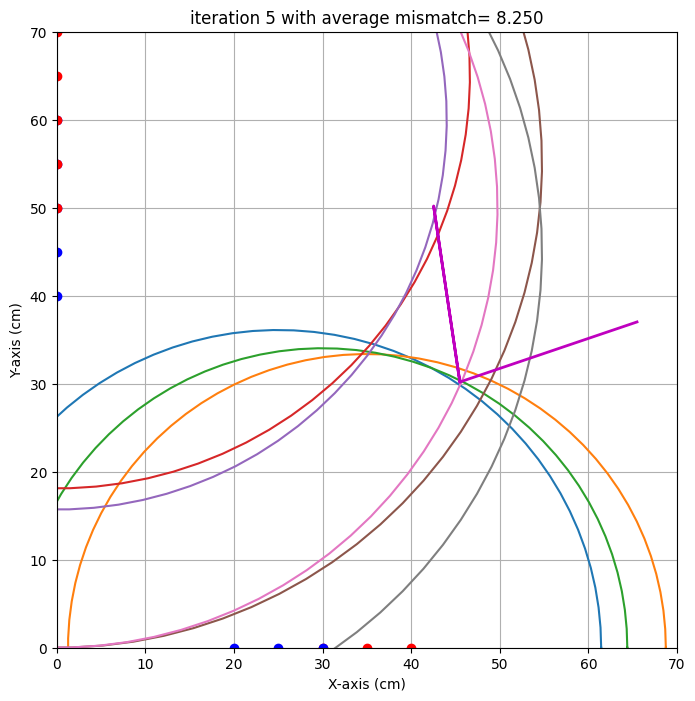

end iteration 5 with average mismatch= 8.250
end iteration 6 with average mismatch= 8.018
end iteration 7 with average mismatch= 8.008
end iteration 8 with average mismatch= 8.007
end iteration 9 with average mismatch= 8.007
end iteration 10 with average mismatch= 8.007
end iteration 11 with average mismatch= 8.007
end iteration 12 with average mismatch= 8.007
end iteration 13 with average mismatch= 8.007
end iteration 14 with average mismatch= 8.007
end iteration 15 with average mismatch= 7.900
end iteration 16 with average mismatch= 7.900
end iteration 17 with average mismatch= 7.900
end iteration 18 with average mismatch= 7.900
end iteration 19 with average mismatch= 7.824
end iteration 20 with average mismatch= 7.824
end iteration 21 with average mismatch= 7.824
end iteration 22 with average mismatch= 7.824
end iteration 23 with average mismatch= 7.824
end iteration 24 with average mismatch= 7.824
end iteration 25 with average mismatch= 7.824
end iteration 26 with average mismatch=

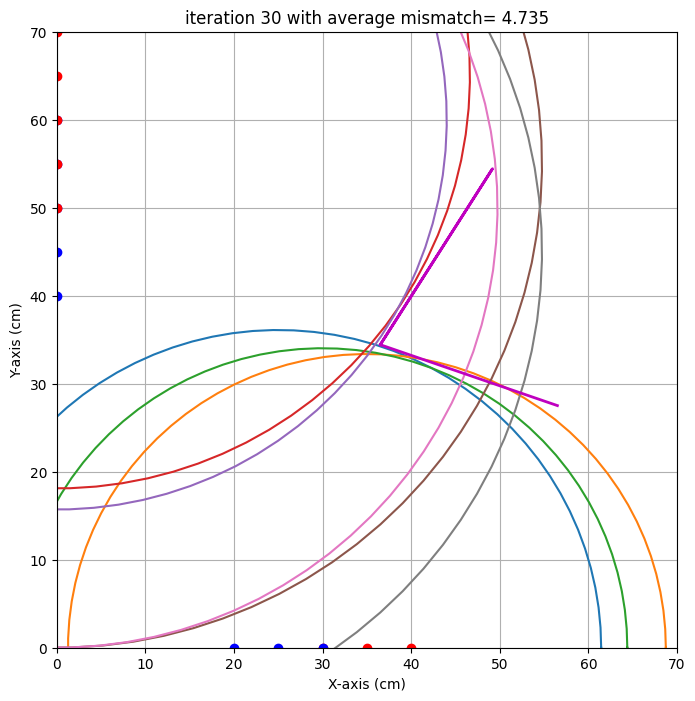

end iteration 30 with average mismatch= 4.735
###############################################################################
end of iteration  30
Best alpha= -19.08 with uncertainty=  13.17
Best beta =  32.36 with uncertainty=   3.80
Best x0   =  36.51 with uncertainty=   0.90
Best y0   =  34.43 with uncertainty=   1.15
###############################################################################


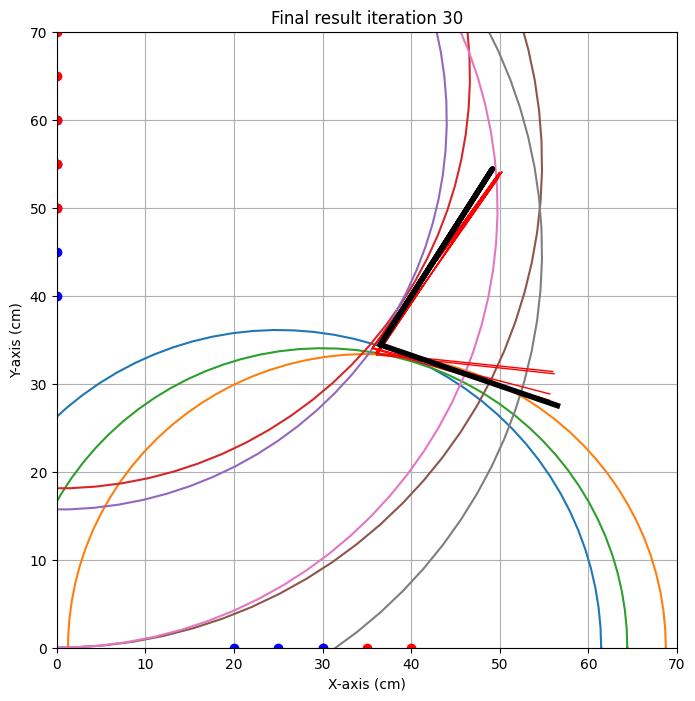

{'alpha': np.float64(-19.077673669022147), 'alpha_eps': np.float64(13.168595946677195), 'beta': np.float64(32.360019412281616), 'beta_eps': np.float64(3.7958479438938824), 'x0': np.float64(36.50660935465219), 'x0_eps': np.float64(0.9028810973119974), 'y0': np.float64(34.431848251913294), 'y0_eps': np.float64(1.1517547851259664)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  110.0
1   0  65   0  55  105.0
2   0  60   0  50  100.0
3   0  55   0  45  105.0
4   0  50   0  40  120.0
5  67   0  57   0  110.0
6  60   0  50   0  107.5
7  55   0  45   0  108.0


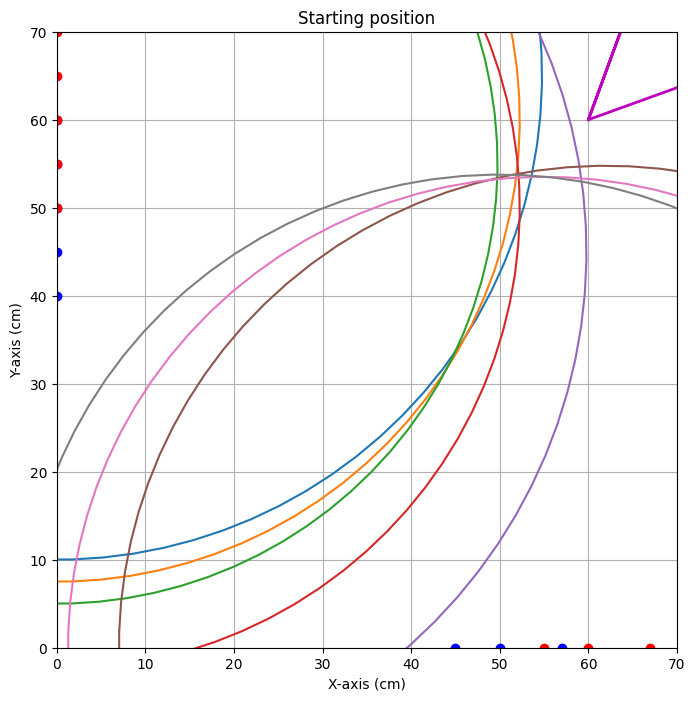


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...



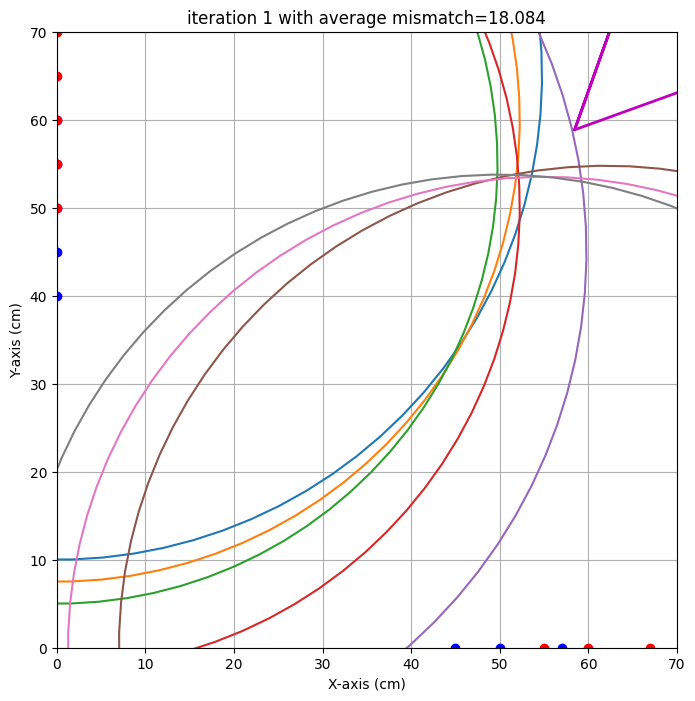

end iteration 1 with average mismatch=18.084


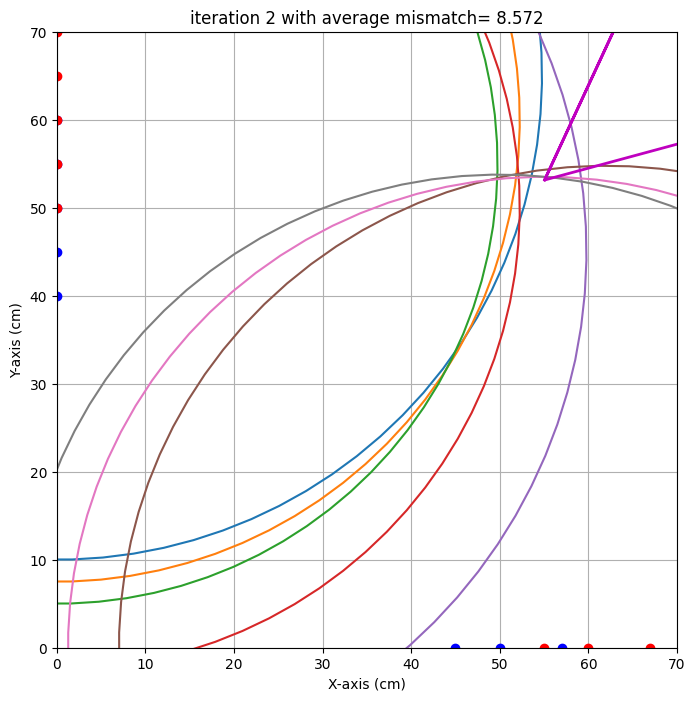

end iteration 2 with average mismatch= 8.572


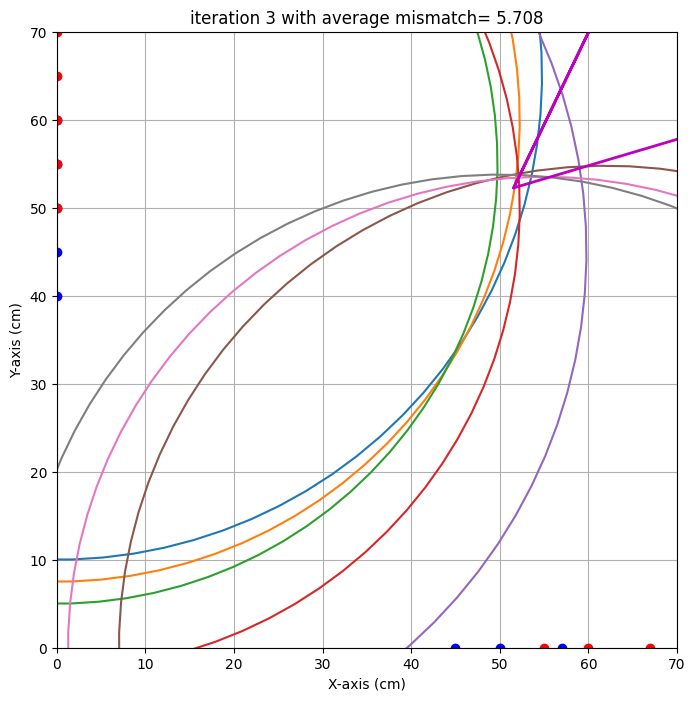

end iteration 3 with average mismatch= 5.708


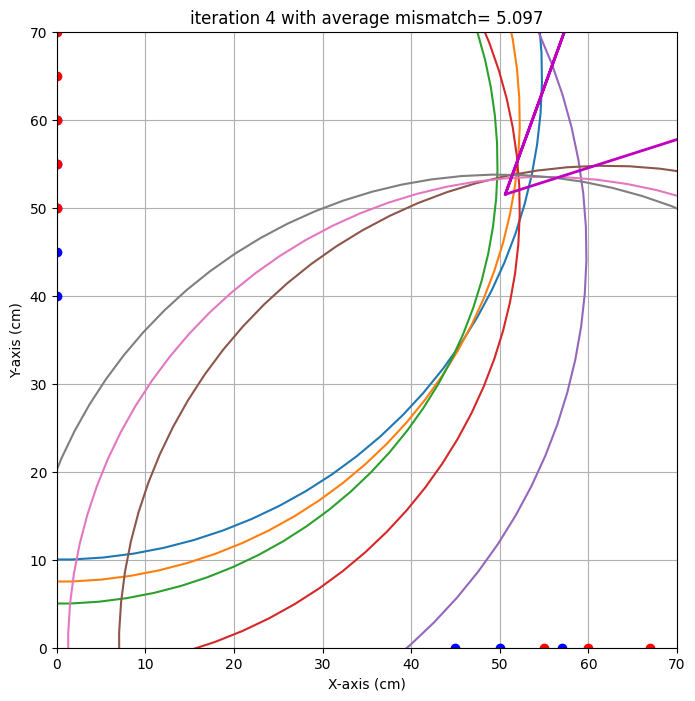

end iteration 4 with average mismatch= 5.097


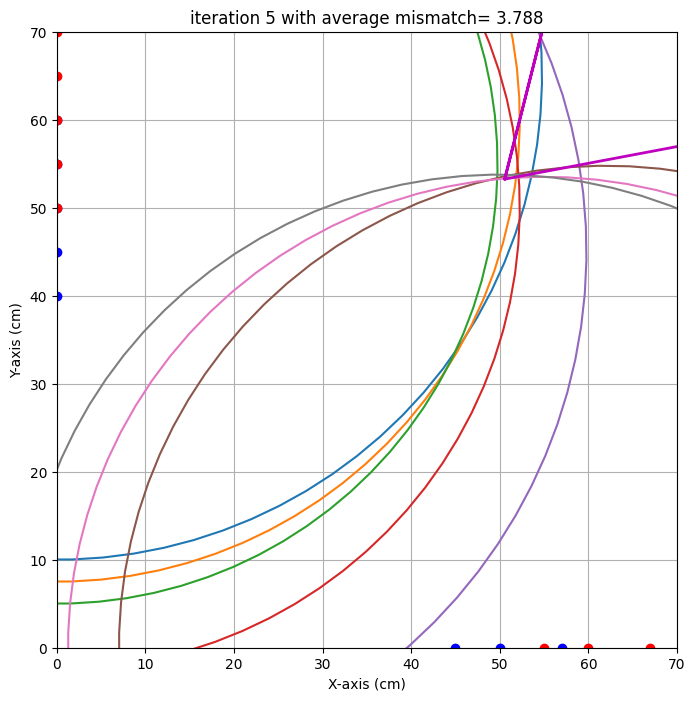

end iteration 5 with average mismatch= 3.788


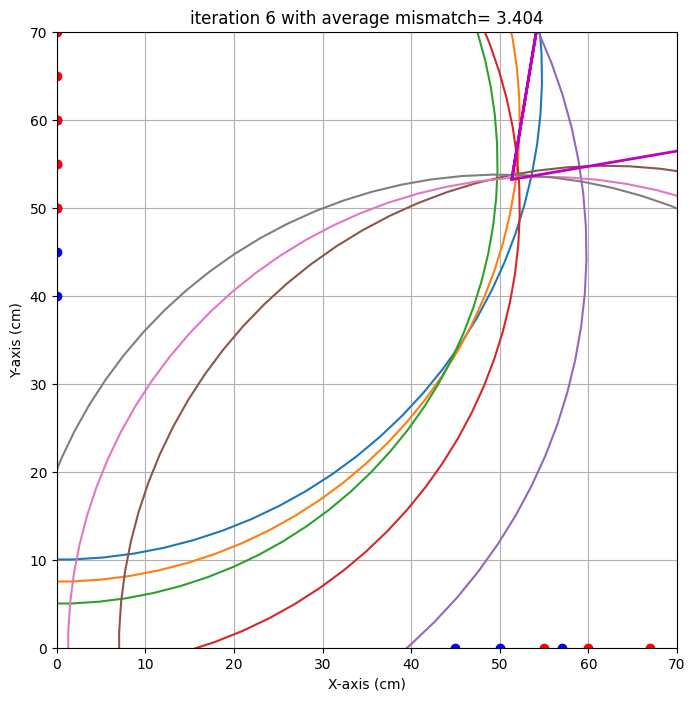

end iteration 6 with average mismatch= 3.404
end iteration 7 with average mismatch= 3.362
end iteration 8 with average mismatch= 3.087
end iteration 9 with average mismatch= 3.087
end iteration 10 with average mismatch= 3.087
end iteration 11 with average mismatch= 3.087
end iteration 12 with average mismatch= 3.087
end iteration 13 with average mismatch= 3.087
end iteration 14 with average mismatch= 3.087
end iteration 15 with average mismatch= 3.070


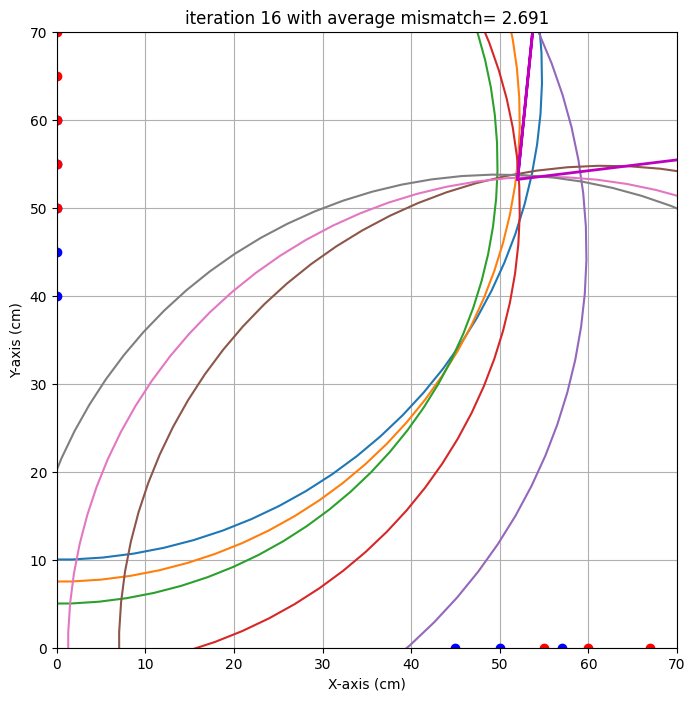

end iteration 16 with average mismatch= 2.691
end iteration 17 with average mismatch= 2.431
end iteration 18 with average mismatch= 2.431
end iteration 19 with average mismatch= 2.374
end iteration 20 with average mismatch= 2.374
end iteration 21 with average mismatch= 2.374
end iteration 22 with average mismatch= 2.374
end iteration 23 with average mismatch= 2.374
end iteration 24 with average mismatch= 2.374
end iteration 25 with average mismatch= 2.374
end iteration 26 with average mismatch= 2.374
end iteration 27 with average mismatch= 2.373
end iteration 28 with average mismatch= 2.373
end iteration 29 with average mismatch= 2.372
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 2.369
###############################################################################
end of iteration  30
Best alpha=   0.56 with uncertainty=  10.20
Best beta =   5.46 with uncertainty=   0.66
Best x0   = 

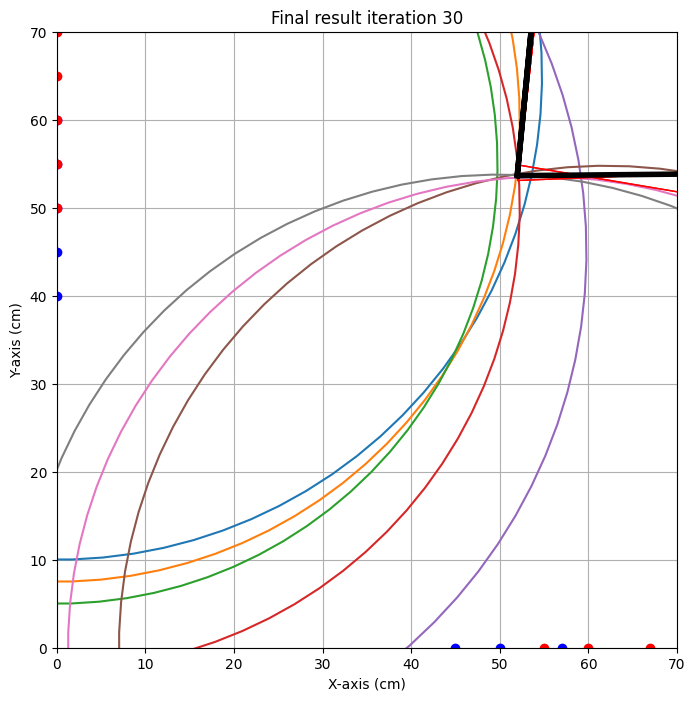

{'alpha': np.float64(0.5559879796104129), 'alpha_eps': np.float64(10.198729859862405), 'beta': np.float64(5.455865286339466), 'beta_eps': np.float64(0.6618923214741548), 'x0': np.float64(51.971545417579065), 'x0_eps': np.float64(0.07990086975169675), 'y0': np.float64(53.640335537093335), 'y0_eps': np.float64(1.2470458874929378)}
locatie 1 
x0 target is : 35.4. Gevonden waarde: 36.5 cm met een standaardafwijking van 0.9 cm 
y0 target is : 34.3. Gevonden waarde: 34.4 cm met een standaardafwijking van 1.2 cm 
alpha target is : -9.0. Gevonden waarde: -19.1 graden met een standaardafwijking van 13.2 graad 
beta target is : 36.0. Gevonden waarde: 32.4 graden met een standaardafwijking van 3.8 graad 

locatie 2 
x0 target is : 45.4. Gevonden waarde: 52.0 cm met een standaardafwijking van 0.1 cm 
y0 target is : 52.4. Gevonden waarde: 53.6 cm met een standaardafwijking van 1.2 cm 
alpha target is : 11.0. Gevonden waarde: 0.6 graden met een standaardafwijking van 10.2 graad 
beta target is : 39.

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 35.4, 
                    'y0': 34.3,
                    'alpha' : -9,
                    'beta' : 36},
            'locatie 2':{'x0': 45.4, 
                    'y0': 52.4,
                    'alpha' : 11,
                    'beta' : 39},
}

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[70,0,60,0,170] ongeldig
    [30,0,20,0,72.9],
    [40,0,30,0,67.5],
    [35,0,25,0,68.8],
    #[25,0,15,0,150] ongeldig
    # dus [20,0,10,0] ook ongeldig
    [0,70,0,60,93.8],
    [0,65,0,55,88.6],
    [0,60,0,50,110.0],
    [0,55,0,45,100],
    [0,50,0,40,110]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [0,70,0,60,110],
        [0,65,0,55,105],
        [0,60,0,50,100],
        [0,55,0,45,105],
        [0,50,0,40,120],
        [67,0,57,0,110],
        [60,0,50,0,107.5],
        [55,0,45,0,108]
        #[50,0,40,0,170] ongeldig
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  20  51.0
1   0  40   0  30  48.0
2  40   0  30   0  55.0
3  35   0  25   0  54.0


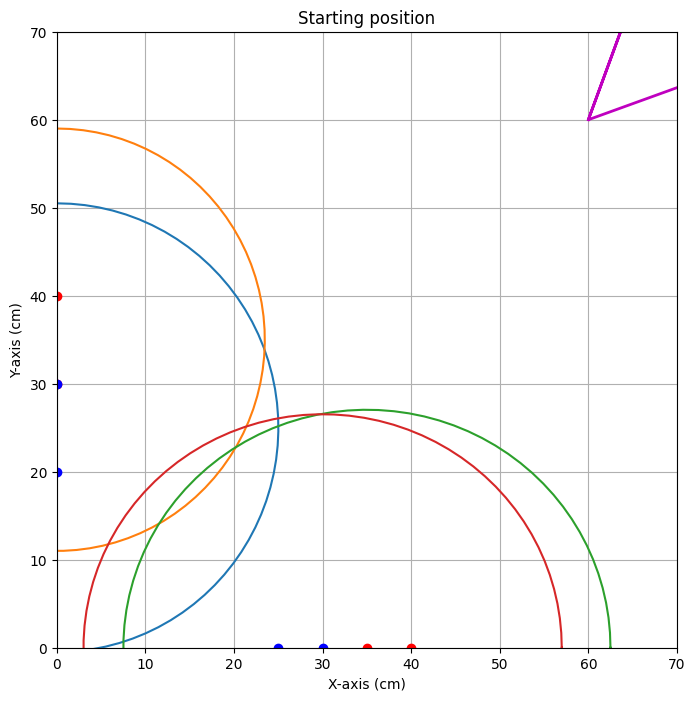


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=88.815


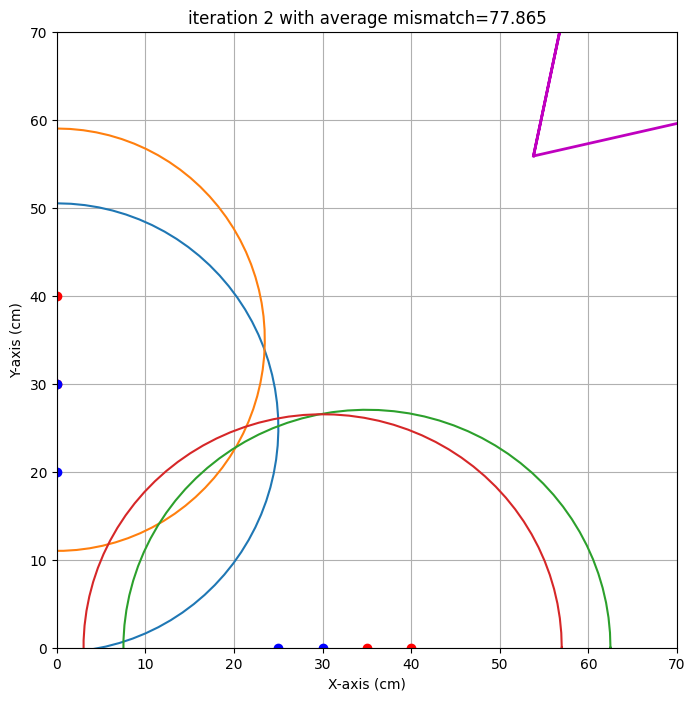

end iteration 2 with average mismatch=77.865


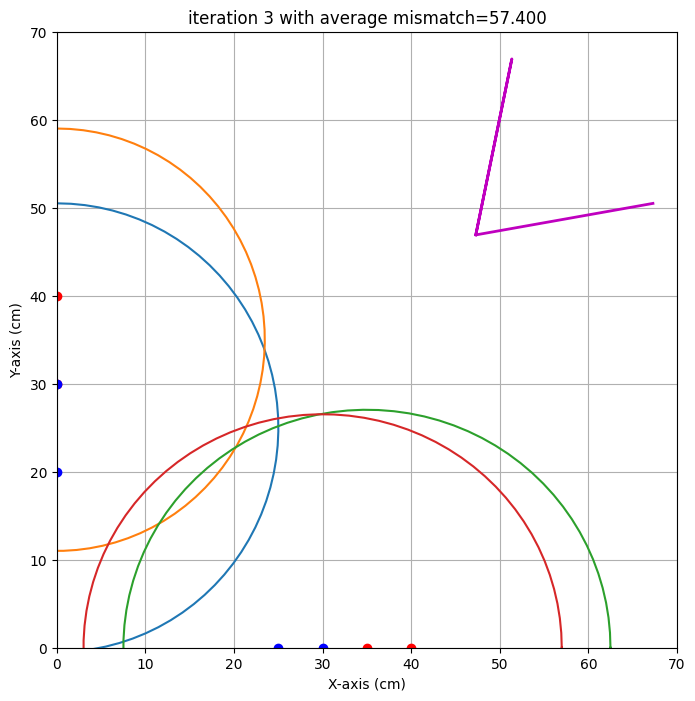

end iteration 3 with average mismatch=57.400


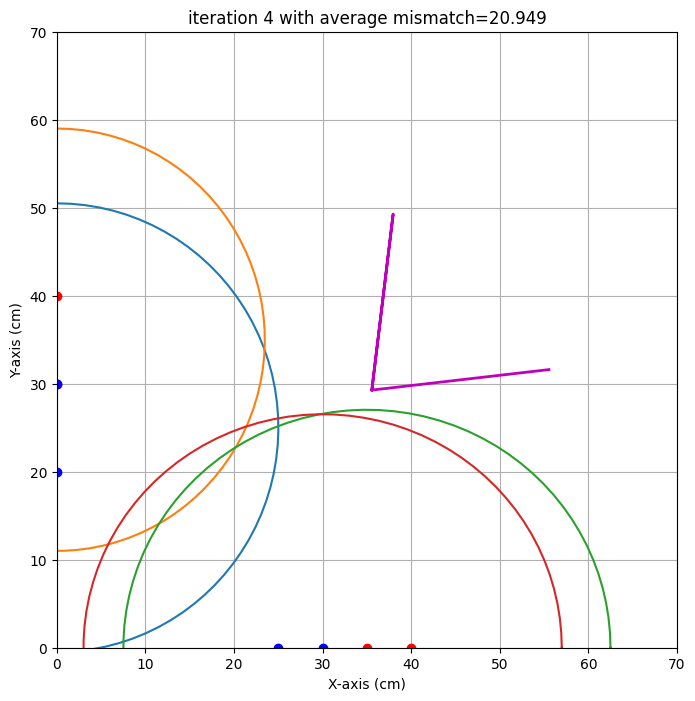

end iteration 4 with average mismatch=20.949


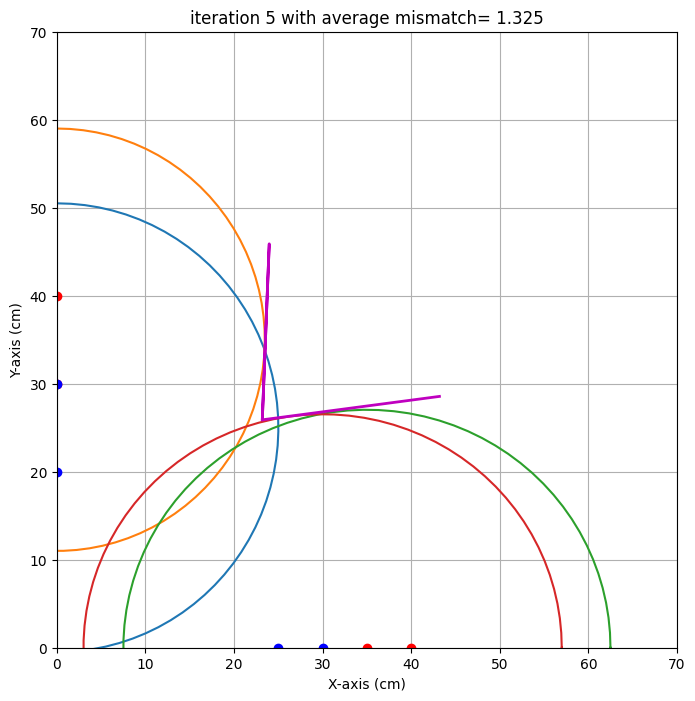

end iteration 5 with average mismatch= 1.325
end iteration 6 with average mismatch= 1.279
end iteration 7 with average mismatch= 1.278
end iteration 8 with average mismatch= 1.277


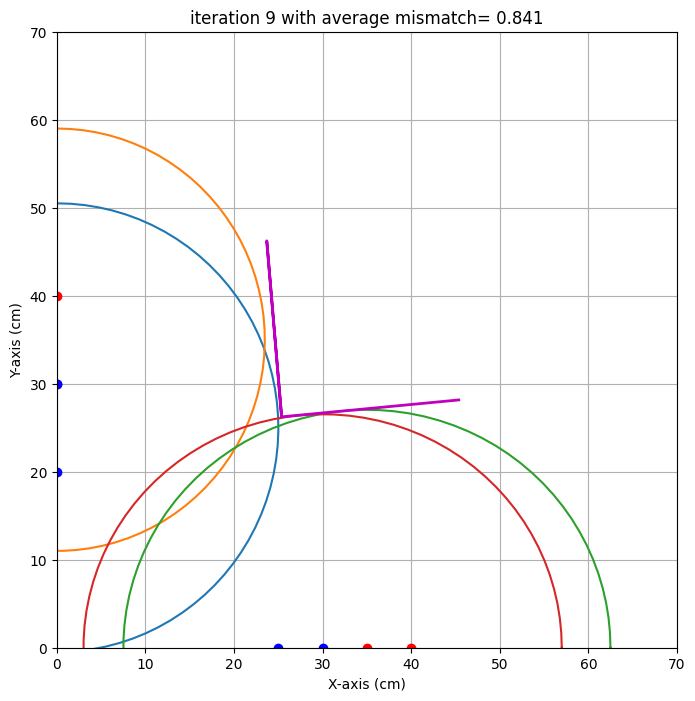

end iteration 9 with average mismatch= 0.841


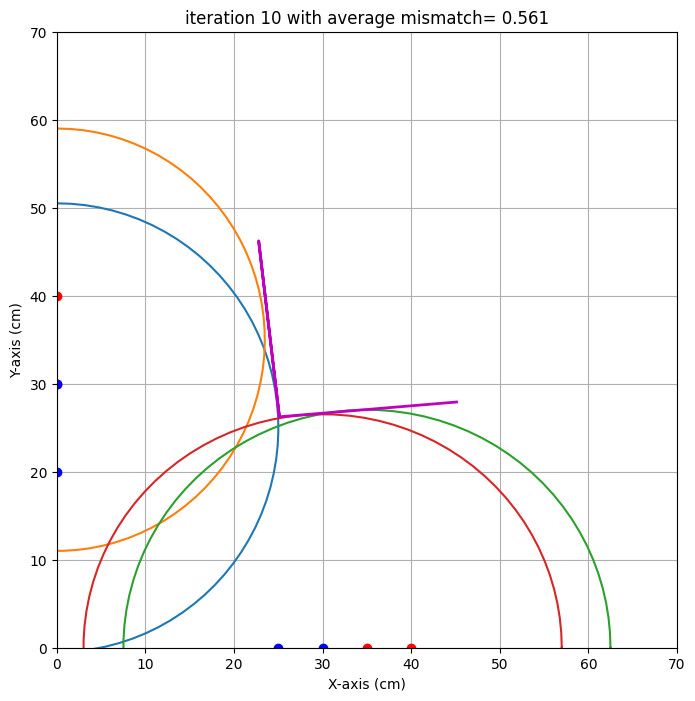

end iteration 10 with average mismatch= 0.561


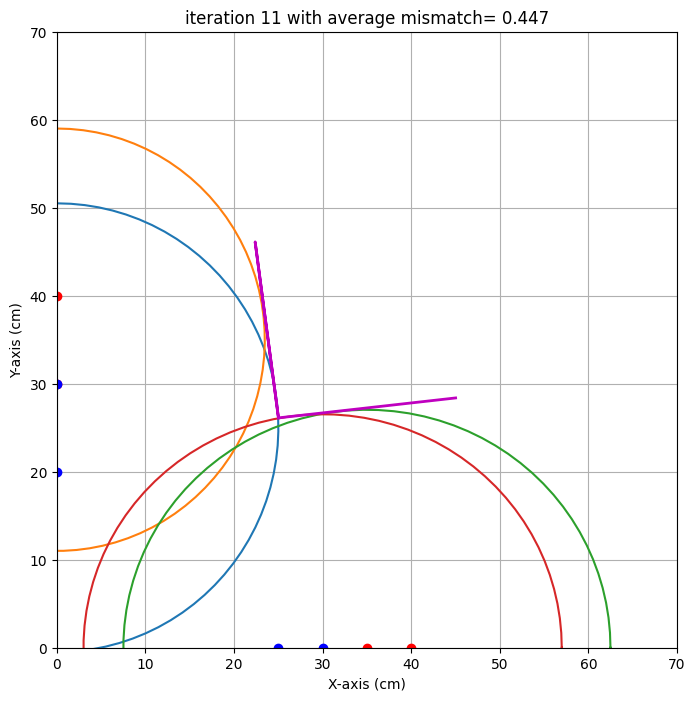

end iteration 11 with average mismatch= 0.447


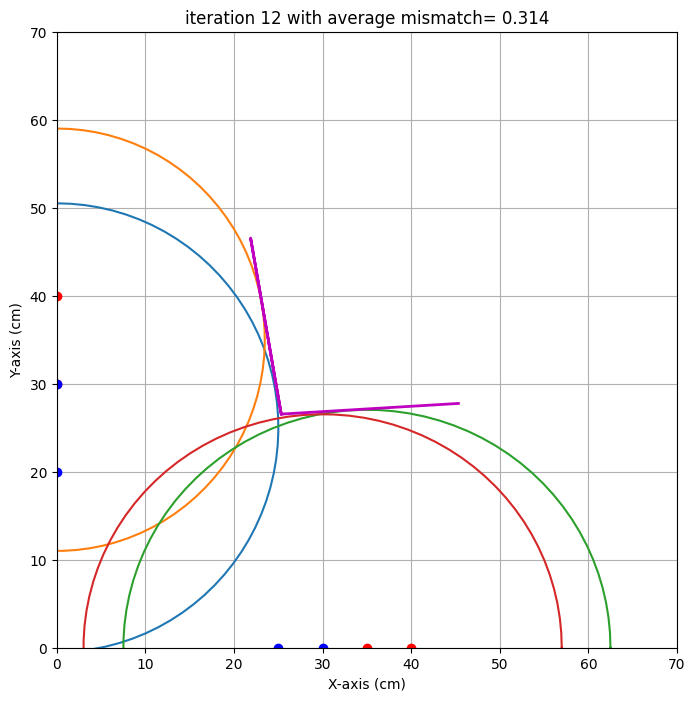

end iteration 12 with average mismatch= 0.314


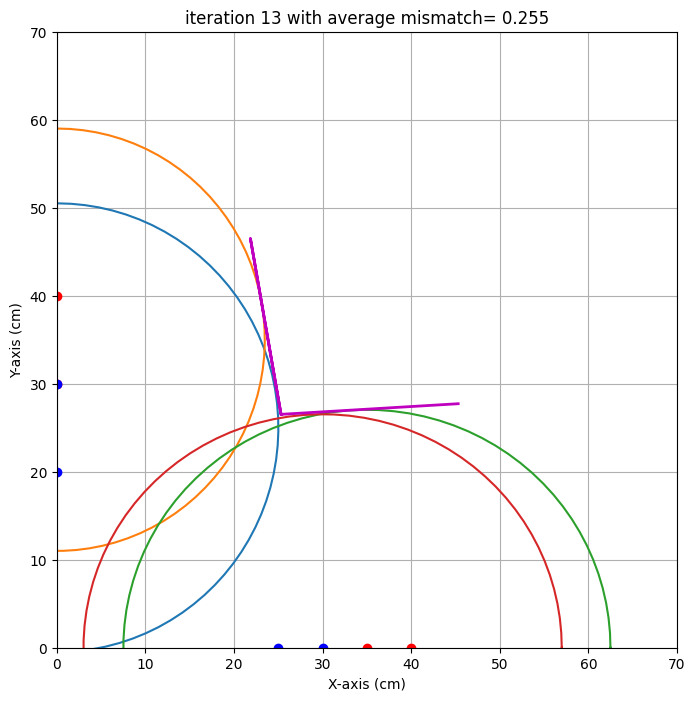

end iteration 13 with average mismatch= 0.255


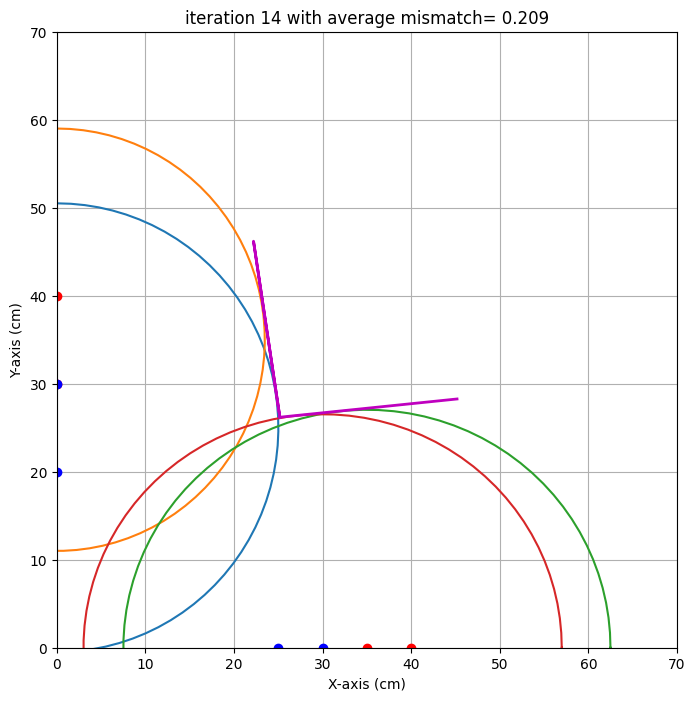

end iteration 14 with average mismatch= 0.209


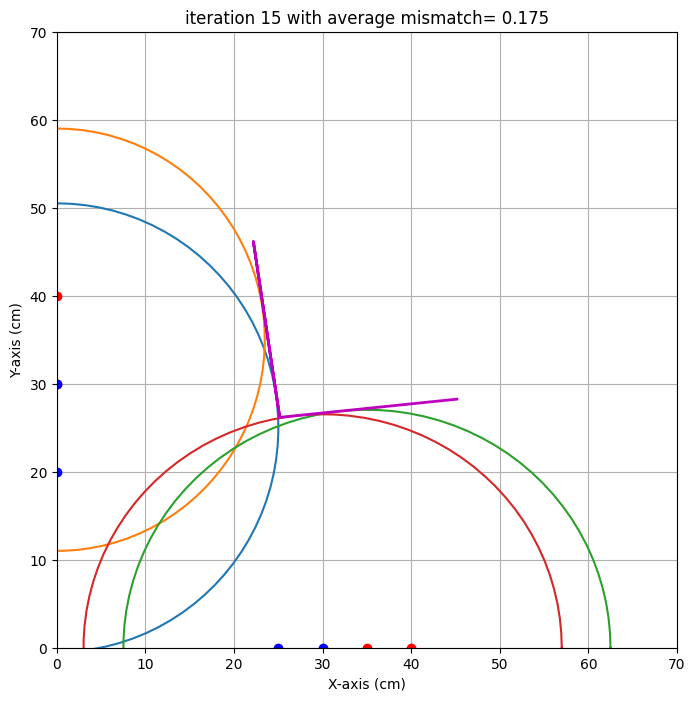

end iteration 15 with average mismatch= 0.175
end iteration 16 with average mismatch= 0.164
end iteration 17 with average mismatch= 0.159
end iteration 18 with average mismatch= 0.159
end iteration 19 with average mismatch= 0.159
end iteration 20 with average mismatch= 0.159
end iteration 21 with average mismatch= 0.159
end iteration 22 with average mismatch= 0.159
end iteration 23 with average mismatch= 0.159
end iteration 24 with average mismatch= 0.159
end iteration 25 with average mismatch= 0.159
end iteration 26 with average mismatch= 0.159
end iteration 27 with average mismatch= 0.159
end iteration 28 with average mismatch= 0.159
end iteration 29 with average mismatch= 0.159
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.159
###############################################################################
end of iteration  30
Best alpha=   5.91 with uncertainty=   2.46
Best beta 

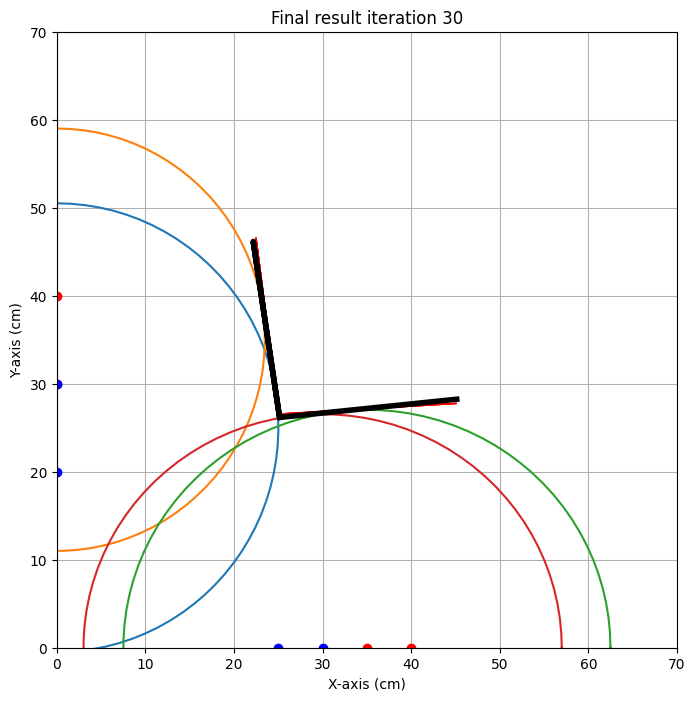

{'alpha': np.float64(5.9054823752825545), 'alpha_eps': np.float64(2.457980108483852), 'beta': np.float64(-8.47584606609582), 'beta_eps': np.float64(1.0979785346985693), 'x0': np.float64(25.140933047143378), 'x0_eps': np.float64(0.07689766231624517), 'y0': np.float64(26.168320284886406), 'y0_eps': np.float64(0.3850027039589605)}
test locatie 
x0 target is : 26.4. Gevonden waarde: 25.1 cm met een standaardafwijking van 0.1 cm 
y0 target is : 25.2. Gevonden waarde: 26.2 cm met een standaardafwijking van 0.4 cm 
alpha target is : 10.0. Gevonden waarde: 5.9 graden met een standaardafwijking van 2.5 graad 
beta target is : -10.0. Gevonden waarde: -8.5 graden met een standaardafwijking van 1.1 graad 



In [14]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA

targets = {'test locatie':{
                    'x0': 26.4,
                    'y0': 25.2,
                    'alpha' : 10,
                    'beta' :  -10,
                          }
            }

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    #[0,70,0,60,170],
                    [0,30,0,20,51.0],
                    [0,40,0,30,48],
                    #[0,20,0,10,150] ongeldig
                    #[70,0,60,0,170] ongeldig
                    #[30,0,20,0,105],
                    [40,0,30,0,55],
                    [35,0,25,0,54],
                    #[30,0,20,0,105]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

Leerdoel 1: inzien dat het maken van een algoritme een ontwerpcyclus is.
#### algoritme [Tim]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Tim.png" width="400">

#### algoritme [Marjoksi]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Marjoksi.png" width="400">

#### algoritme [Steven]
Voeg een foto in van het algoritme van het derde groepslid
<img src="Steven.png" width="400">

Nadat we inzagen dat we het verkeerd begrepen hadden, hebben we het meetalgoritme verbeterd tot onze uiteindelijke algoritme:
Figuur: ![Alt](Eindalgoritme.png)



Leerdoel 2: De ontwerpcyclus optimaal inrichten op de randvoorwaarden van de ontwerpopdracht:
Zie fotos